# What quantum mechanics changes — distinguishability, no-cloning, information versus disturbance, monogamy, quantum channels and their capacities

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 14 — Quantum communication and cryptography*

## 1. Introduction and motivation

The first two notebooks of this chapter treated communication with classical signals. Bits sent through a noisy
channel can be protected by error correction, and a message can be made perfectly secret with a one-time pad, but only
if Alice and Bob already share a secret random key as long as the message. On a classical line Eve can copy every
signal without leaving a trace, so Alice and Bob have no way of bounding what she knows. This notebook asks what
changes when the signals are quantum states. Can Eve still copy them? Can she learn something about them without being
noticed? And how much classical or quantum information can a noisy quantum channel carry at all?

![An eavesdropper on a quantum channel couples a probe to the qubit with a unitary; she cannot keep a copy, and the information she gains shows up as errors at Bob. Every channel is a coupling to an environment and has a Kraus form](figures/quantum_rules.svg)

**Figure 1.** What quantum mechanics changes. (a) Eve can only let Alice's qubit interact with a probe of her own,
with some unitary $U$, and measure the probe later. She cannot turn a blank probe into a copy of an unknown state
(Section 4), and if Alice's signal states are nonorthogonal, any information that Eve's probe acquires shows up as
errors in Bob's results (Section 5). (b) Every physical channel arises in the same way: the signal interacts with an
environment, which is then discarded. The result is the Kraus form of the channel (Section 8). In cryptography the
environment is assumed to be in Eve's hands, and the capacities of Section 9 count what reaches Bob.

**The idea.** Quantum mechanics places three limits on everybody, Eve included. Nonorthogonal states cannot be
distinguished with certainty, so a single copy of an unknown state reveals only part of its identity. Unknown states
cannot be copied. And information about which of two nonorthogonal states was sent can be gained only at the price of
disturbing them. The third limit turns into a security guarantee: Alice and Bob compare part of their data, measure
the error rate, and infer an upper bound on what Eve can know. Entanglement adds a fourth rule with the same effect:
a pair that is maximally entangled cannot be correlated with anything else. The second half of the notebook turns from
eavesdroppers to noise. A quantum channel is described by its Kraus operators, and its usefulness is measured by
capacities, the quantum counterparts of Shannon's capacity of notebook 50: how many classical bits, and how many
qubits, it carries reliably per use.

### 1.1 Road map

* **Section 3** proves that nonorthogonal states cannot be distinguished with certainty and derives the Helstrom
  bound on the best probability of success, checked by optimising over measurements for $\vert0\rangle$ against
  $\vert+\rangle$.
* **Section 4** recalls the no-cloning theorem of notebook 20 and adds its consequences for communication, with a
  measure-and-prepare copier applied to the four BB84 states.
* **Section 5** proves that information gain implies disturbance and simulates a probe attack of tunable strength on
  BB84 states: Eve's information against the error rate seen by Bob.
* **Section 6** recalls the Bell states, local operations and classical communication, and no-signalling, and proves
  and checks the monogamy of entanglement.
* **Section 7** summarises the resource accounting of teleportation and superdense coding.
* **Section 8** introduces quantum channels and four examples: depolarising, dephasing, amplitude damping and erasure.
* **Section 9** defines the classical capacity with the Holevo bound, the quantum capacity with the coherent
  information, and the entanglement-assisted capacity, and computes them for these channels.
* **Section 10** collects what quantum key distribution takes from these results.

### What you will learn

*Physics and information*

* why a measurement cannot tell nonorthogonal states apart with certainty, and the Helstrom bound
  $P_{\rm succ}=(1+D)/2$ with the trace distance $D$;
* why Eve cannot copy a qubit in transit, and why a quantum signal cannot be amplified;
* the theorem that information gain implies disturbance, and the trade-off curve of a concrete probe attack;
* monogamy: a pure entangled pair is uncorrelated with every third system, and a pair close to a Bell state is
  nearly so;
* quantum channels in Kraus form and their action on the Bloch ball;
* the Holevo quantity $\chi$ and why one qubit carries at most one classical bit; the coherent information and the
  quantum capacities of the erasure and dephasing channels; the entanglement-assisted capacity.

*Numerical methods*

* scans over measurement directions and over input ensembles as numerical checks of optimality statements;
* von Neumann entropies of reduced density matrices from density tensors, with a reference system that purifies the
  channel input;
* sampling of protocol rounds from exact joint outcome distributions.

*Implementation practice*

* states as tensors, gates with `apply_gate`, channels with `apply_kraus_dm`, partial traces with `rdm` and `rdm_dm`;
* wrong controls that must fail: a measurement in the wrong basis, orthogonal signals that Eve can copy without
  disturbance, a classically correlated pair that Eve shares completely, and inputs that do not reach a capacity.

### Prerequisites

* [Notebook 50](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb):
  entropy, the binary entropy $h(q)$, the mutual information, and the capacity of a classical channel (Section 5,
  in particular $C_{\rm BSC}=1-h(q)$ and $C_{\rm BEC}=1-e$, Eq. (16) there).
* [Notebook 51](../ch14_quantum_communication_and_cryptography/51_secrecy_one_time_pad_and_authentication.ipynb):
  the threat model and why Alice and Bob need a bound on Eve's knowledge (Sections 3 and 10 there).
* [Notebook 07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): density matrices, the
  Bloch ball, density tensors and the Kraus form of a channel.
* [Notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb), Sections 5–6 (trace distance,
  Schmidt decomposition), and [notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb), Section 3.1 (general
  measurements).
* [Notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb),
  [notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb) and
  [notebook 21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb): the Bell
  states, teleportation with the no-cloning theorem, and superdense coding with the Holevo bound.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

States are tensors of shape $(2,)^N$ and density matrices are tensors of shape $(2,)^{2N}$, as in notebook 07. Gates
act with `apply_gate`, channels with `apply_kraus_dm`, and partial traces are taken with `rdm` (from a pure state) or
`rdm_dm` (from a density tensor). The channel and the entropy are called thousands of times in the scans below, so
they are compiled once with `jax.jit` (`kraus_apply` is `apply_kraus_dm` compiled). Entropies are in bits throughout.
Every random experiment draws its numbers from its own key `jax.random.fold_in(MASTER, i)`, so the experiments are
reproducible one by one.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

MASTER = jax.random.PRNGKey(52)          # one master key per run; experiment i uses fold_in(MASTER, i)


def key_for(i):
    """Independent key for experiment number i."""
    return jax.random.fold_in(MASTER, i)


def h2(q):
    """Binary entropy h(q) in bits (notebook 50, Eq. (4)); scalars and arrays, 0 log 0 = 0."""
    q = np.asarray(q, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = -q * np.log2(np.where(q > 0, q, 1.0)) - (1 - q) * np.log2(np.where(q < 1, 1 - q, 1.0))
    return out if out.ndim else float(out)


def shannon(probs):
    """Shannon entropy in bits of a probability vector (notebook 50, Eq. (2))."""
    p = np.asarray(probs, dtype=float).ravel()
    p = p[p > 1e-15]
    return float(-(p * np.log2(p)).sum()) + 0.0


_vn_entropy = jax.jit(von_neumann_entropy)
_kraus_jit = jax.jit(apply_kraus_dm, static_argnums=2)


def S_vn(rho_mat):
    """Von Neumann entropy S(rho) = -Tr rho log2 rho of a density MATRIX, as a Python float."""
    return float(_vn_entropy(jnp.asarray(rho_mat, dtype=CDTYPE))) + 0.0


def kraus_apply(rho, kraus, qubits):
    """apply_kraus_dm compiled with jax.jit (one compilation per shape and qubit list)."""
    return _kraus_jit(jnp.asarray(rho, dtype=CDTYPE), jnp.asarray(kraus, dtype=CDTYPE), tuple(qubits))


def mutual_info(pxy):
    """Mutual information I(X:Y) in bits of a joint probability table (notebook 50, Eq. (10))."""
    pxy = np.asarray(pxy, dtype=float)
    return shannon(pxy.sum(1)) + shannon(pxy.sum(0)) - shannon(pxy)


def bloch(rho_mat):
    """Bloch vector (r_x, r_y, r_z) = (Tr rho X, Tr rho Y, Tr rho Z) of a one-qubit density matrix."""
    return np.array([float(jnp.real(jnp.trace(rho_mat @ P))) for P in (X, Y, Z)])


def ket(theta, phi=0.0):
    """One qubit on the Bloch sphere: cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>."""
    return jnp.array([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)], dtype=CDTYPE)


def proj(v):
    """Projector |v><v| onto a normalised vector v."""
    v = jnp.asarray(v, dtype=CDTYPE).reshape(-1)
    return jnp.outer(v, jnp.conj(v))


KET0, KET1 = product_state("0"), product_state("1")
KETP, KETM = product_state("+"), product_state("-")
BB84 = {"0": (KET0, "Z"), "1": (KET1, "Z"), "+": (KETP, "X"), "-": (KETM, "X")}   # state, basis

## 3. Distinguishing quantum states

### 3.1 Orthogonal states can be told apart, nonorthogonal states cannot

Suppose Bob receives one of two known states, $\vert\psi\rangle$ or $\vert\varphi\rangle$, and has to say which. If
the two are orthogonal, he measures in a basis that contains both and is always right; this is the situation of
classical bits, which are just orthogonal states. If they are not orthogonal, no measurement succeeds with certainty.

**Proof.** A perfect two-outcome measurement would have projectors $P_\psi$ and $P_\varphi=\mathbb 1-P_\psi$ with
$P_\varphi\vert\psi\rangle=0$, so that $\vert\psi\rangle$ never gives the answer "$\varphi$". Decompose
$\vert\varphi\rangle=\alpha\vert\psi\rangle+\beta\vert\psi^\perp\rangle$ with $\vert\psi^\perp\rangle$ orthogonal to
$\vert\psi\rangle$ and $\alpha=\langle\psi\vert\varphi\rangle\neq0$. Then $P_\varphi\vert\varphi\rangle=
\beta P_\varphi\vert\psi^\perp\rangle$, and the probability that $\vert\varphi\rangle$ gives the correct answer is

$$\langle\varphi\vert P_\varphi\vert\varphi\rangle=\vert\beta\vert^2\langle\psi^\perp\vert P_\varphi\vert\psi^\perp
\rangle\leq\vert\beta\vert^2=1-\vert\langle\psi\vert\varphi\rangle\vert^2<1. \tag{1}$$

A measurement that never errs on $\vert\psi\rangle$ must err on $\vert\varphi\rangle$ with probability at least
$\vert\langle\psi\vert\varphi\rangle\vert^2$. One copy of a quantum state therefore does not reveal which of several
nonorthogonal states it is. The BB84 protocol of the next notebook of this chapter sends exactly such states:
$\vert0\rangle$, $\vert1\rangle$, $\vert+\rangle$ and $\vert-\rangle$, where every state of one basis has overlap
$\vert\langle0\vert+\rangle\vert^2=1/2$ with both states of the other.

### 3.2 The Helstrom bound

Equation (1) says that perfect discrimination is impossible; the next question is how well Bob can do. Let the two
possibilities be density matrices $\rho$ and $\sigma$, each sent with probability $1/2$, and let Bob's measurement
answer "$\rho$" with the operator $\Pi$ and "$\sigma$" with $\mathbb 1-\Pi$, where $0\leq\Pi\leq\mathbb 1$ means
that $\Pi$ is Hermitian with all eigenvalues between $0$ and $1$. This includes general measurements: in the notation
of notebook 08, Section 3.1, $\Pi=M_0^\dagger M_0$, and the answer "$\rho$" has probability ${\rm Tr}[\rho\,\Pi]$.
His probability of success is

$$P_{\rm succ}=\tfrac12{\rm Tr}[\rho\,\Pi]+\tfrac12{\rm Tr}[\sigma(\mathbb 1-\Pi)]
=\tfrac12+\tfrac12{\rm Tr}\big[\Pi(\rho-\sigma)\big]. \tag{2}$$

Write the Hermitian difference in its eigenbasis, $\rho-\sigma=\sum_i\lambda_i\vert i\rangle\langle i\vert$. Then
${\rm Tr}[\Pi(\rho-\sigma)]=\sum_i\lambda_i\langle i\vert\Pi\vert i\rangle$, and since $0\leq\langle i\vert\Pi\vert
i\rangle\leq1$ the sum is largest when $\Pi$ projects onto the eigenvectors with positive $\lambda_i$. The maximum is
the sum of the positive eigenvalues, which equals $\tfrac12\sum_i\vert\lambda_i\vert$ because ${\rm
Tr}(\rho-\sigma)=0$. That number is the **trace distance** $D(\rho,\sigma)$ of notebook 06, Section 5, so the best
probability of success is the **Helstrom bound** (Helstrom 1976)

$$P_{\rm succ}^{\max}=\frac{1+D(\rho,\sigma)}2,\qquad D(\rho,\sigma)=\tfrac12\sum_i\vert\lambda_i\vert. \tag{3}$$

For two pure states $\rho-\sigma$ has rank two and trace zero, so its eigenvalues are $\pm\lambda$, and
${\rm Tr}[(\rho-\sigma)^2]=2-2\vert\langle\psi\vert\varphi\rangle\vert^2=2\lambda^2$ gives

$$D=\sqrt{1-\vert\langle\psi\vert\varphi\rangle\vert^2}. \tag{4}$$

For $\vert0\rangle$ against $\vert+\rangle$ the overlap is $1/2$, so $D=1/\sqrt2$ and
$P_{\rm succ}^{\max}=(1+1/\sqrt2)/2=0.854$. The optimal projector points along the Bloch direction of $\rho-\sigma$,
halfway between $+z$ and $-x$. The next cell computes $D$ with the engine, scans all projective measurements over the
Bloch sphere, tries $5000$ random two-outcome general measurements, and simulates $10^5$ guesses with the optimal
measurement. The wrong control measures in the $Z$ basis, which identifies $\vert0\rangle$ perfectly but
$\vert+\rangle$ only half of the time.

In [4]:
# ==============================================================================
# Eqs. (2)-(4): Helstrom bound for |0> vs |+>, checked against all measurements
# ==============================================================================
rho_a, rho_b = proj(KET0), proj(KETP)
D_ab = float(trace_distance(rho_a, rho_b))
P_helstrom = (1 + D_ab) / 2                                               # Eq. (3)
ov2 = float(jnp.abs(jnp.vdot(KET0, KETP)) ** 2)
assert abs(D_ab - np.sqrt(1 - ov2)) < TOL                                 # Eq. (4)


def p_succ(Pi):
    """Eq. (2): success probability of the measurement {Pi, 1 - Pi} for equiprobable rho_a, rho_b.
    Pi may carry leading batch axes, (..., 2, 2)."""
    return 0.5 + 0.5 * np.asarray(jnp.real(jnp.einsum("...ij,ji->...", Pi, rho_a - rho_b)))


# all projective measurements: Pi = |n><n| for Bloch directions n on a (theta, phi) grid, one batched call
thetas, phis = np.linspace(0, np.pi, 61), np.linspace(0, 2 * np.pi, 121)
T_, F_ = np.meshgrid(thetas, phis, indexing="ij")
n_vec = jnp.stack([jnp.cos(T_ / 2), jnp.exp(1j * F_) * jnp.sin(T_ / 2)], axis=-1).astype(CDTYPE)   # ket(theta, phi)
grid = p_succ(jnp.einsum("...i,...j->...ij", n_vec, jnp.conj(n_vec)))
i_best, j_best = np.unravel_index(grid.argmax(), grid.shape)
print(f"trace distance D = {D_ab:.6f} = sqrt(1 - |<0|+>|^2) = {np.sqrt(1 - ov2):.6f}")
print(f"Helstrom bound (1 + D)/2 = {P_helstrom:.6f}")
print(f"best projective measurement on the grid: P = {grid.max():.6f} at theta = {thetas[i_best]:.3f}, "
      f"phi = {phis[j_best]:.3f}  (optimum theta = pi/4 = {np.pi / 4:.3f}, phi = pi)")
assert grid.max() <= P_helstrom + TOL and P_helstrom - grid.max() < 1e-3

# random general measurements 0 <= Pi <= 1: Pi = V diag(u) V^dag with random unitary V and u in [0, 1]
rng = np.random.default_rng(int(jax.random.randint(key_for(1), (), 0, 2**31 - 1)))
A = rng.normal(size=(5_000, 2, 2)) + 1j * rng.normal(size=(5_000, 2, 2))
V, _r = np.linalg.qr(A)                                                   # 5000 random unitaries
Pi_rand = jnp.asarray(np.einsum("nij,nj,nkj->nik", V, rng.uniform(0, 1, (5_000, 2)), V.conj()), dtype=CDTYPE)
best_random = float(p_succ(Pi_rand).max())
print(f"best of 5000 random general measurements: P = {best_random:.6f}")
assert best_random <= P_helstrom + TOL

# simulation: 10^5 rounds, Alice sends |0> or |+> at random, Bob uses the optimal projector
w, v = jnp.linalg.eigh(rho_a - rho_b)
Pi_opt = proj(v[:, 1])                                                    # eigenvector of the positive eigenvalue
N_SHOTS = 100_000
k1, k2 = jax.random.split(key_for(2))
sent = np.asarray(jax.random.bernoulli(k1, 0.5, (N_SHOTS,)))              # 0 -> |0>, 1 -> |+>
p_say_a = np.array([float(jnp.real(jnp.trace(Pi_opt @ r))) for r in (rho_a, rho_b)])   # P(answer "|0>" | sent)
u = np.asarray(jax.random.uniform(k2, (N_SHOTS,)))
says_a = u < p_say_a[sent.astype(int)]
rate = float(np.mean(says_a == (sent == 0)))
se = np.sqrt(P_helstrom * (1 - P_helstrom) / N_SHOTS)
print(f"simulated success rate with the optimal measurement: {rate:.4f} +- {se:.4f}")
assert abs(rate - P_helstrom) < 5 * se

# wrong control: measure in the Z basis and answer |0> for outcome 0
P_Z = float(p_succ(proj(KET0)))
print(f"wrong control, Z-basis measurement: P = {P_Z:.4f}")
assert abs(P_Z - 0.75) < TOL and P_Z < P_helstrom - 0.1

trace distance D = 0.707107 = sqrt(1 - |<0|+>|^2) = 0.707107
Helstrom bound (1 + D)/2 = 0.853553
best projective measurement on the grid: P = 0.853553 at theta = 0.785, phi = 3.142  (optimum theta = pi/4 = 0.785, phi = pi)


best of 5000 random general measurements: P = 0.838113


simulated success rate with the optimal measurement: 0.8529 +- 0.0011
wrong control, Z-basis measurement: P = 0.7500


The trace distance is $0.7071$, and no projective measurement on the grid and none of the $5000$ random general
measurements beats $(1+D)/2=0.8536$; the best grid point sits at $\theta=\pi/4$, $\varphi=\pi$, the direction halfway
between the Bloch vectors of $\vert0\rangle$ and $\vert-\rangle$. A simulation of $10^5$ rounds with this measurement
is right in $85.3\,\%$ of them, within one standard error of the bound. The $Z$ measurement reaches only $3/4$: it
is always right on $\vert0\rangle$ and
guesses at random on $\vert+\rangle$. Whatever the receiver does, one copy of $\vert0\rangle$ or $\vert+\rangle$ is
misidentified with probability at least $14.6\,\%$, and this applies to Eve as much as to Bob.

## 4. No-cloning and its consequences for communication

**The theorem.** No unitary $U$ and no blank state $\vert e\rangle$ satisfy $U\vert\psi\rangle\vert e\rangle=
\vert\psi\rangle\vert\psi\rangle$ for every $\vert\psi\rangle$ (Wootters and Zurek 1982; Dieks 1982). Unitaries
preserve inner products, so cloning two states would require $\langle\psi\vert\varphi\rangle=\langle\psi\vert
\varphi\rangle^2$, which allows only orthogonal or identical states.
[Notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb), Section 3, proves the theorem by
linearity and by inner products, shows that the CNOT "copier" entangles instead of copying, and quotes the optimal
approximate cloner.

For communication the theorem has three direct consequences.

* **Eve cannot keep a copy.** She cannot copy a qubit in transit, keep the copy for later and forward the original.
  Whatever she keeps is correlated with the signal only as far as Section 5 allows.
* **A quantum signal cannot be amplified.** An ideal amplifier would turn one photon in an unknown state into many
  photons in the same state, which is a cloner. Losses in an optical fibre therefore cannot be compensated by
  amplifiers as in classical telecommunication. Long-distance quantum communication needs other tools, entanglement
  swapping and purification in quantum repeaters, which are the subject of the last part of this chapter.
* **Classical information can be copied.** Orthogonal states can be measured in their basis and prepared again as
  often as desired. This is what Eve does to classical bits, and it is the reason why classical key distribution
  gives no way of detecting her.

### 4.1 A measure-and-prepare copier on the BB84 states

Eve can always produce many approximate copies by measuring and preparing: she measures the signal along some Bloch
direction $\mathbf n$ and prepares as many qubits as she wants in the state indicated by the outcome. How good are
the copies when the input is one of the four BB84 states? A one-qubit state with Bloch vector $\mathbf r_{\rm in}$
gives outcome $\pm$ with probability $(1\pm\mathbf n\cdot\mathbf r_{\rm in})/2$, and if Eve prepares the Bloch vector
$\pm\mathbf m$ after outcome $\pm$, the fidelity of each copy with the input, $F=\langle\psi\vert\rho_{\rm out}
\vert\psi\rangle=\tfrac12(1+\mathbf r_{\rm in}\cdot\mathbf r_{\rm out})$ (insert $\rho_{\rm out}=\tfrac12(\mathbb 1+
\mathbf r_{\rm out}\cdot\boldsymbol\sigma)$ and use $\langle\psi\vert\boldsymbol\sigma\vert\psi\rangle=\mathbf r_{\rm
in}$), averages to

$$\bar F=\tfrac12+\tfrac12\,\overline{(\mathbf n\cdot\mathbf r_{\rm in})(\mathbf m\cdot\mathbf r_{\rm in})}
=\tfrac12+\tfrac14\,(n_zm_z+n_xm_x)\;\leq\;\tfrac34 , \tag{5}$$

where the bar is the average over $\mathbf r_{\rm in}\in\{\pm\hat z,\pm\hat x\}$. The maximum $3/4$ is reached for
every measurement direction in the $x$–$z$ plane, provided Eve prepares along the same direction ($\mathbf m=
\mathbf n$). Measuring in the $Z$ basis copies $\vert0\rangle$ and $\vert1\rangle$ perfectly and $\vert\pm\rangle$
with fidelity $1/2$; measuring in the basis halfway between $Z$ and $X$ spreads the same average evenly. Averaged over
the whole Bloch sphere instead of the four BB84 states, the best measure-and-prepare fidelity is $2/3$, the classical
benchmark of notebook 20, Section 8. The next cell runs the copier with the engine: the measurement is a projector,
the preparation is a fresh qubit, and the fidelity is computed for two output copies.

In [5]:
# ==============================================================================
# Eq. (5): measure-and-prepare copying of the four BB84 states
# ==============================================================================
def measure_prepare_copies(psi_in, theta_meas, phi_meas=0.0, n_copies=2):
    """Measure psi_in along the Bloch direction (theta_meas, phi_meas), prepare n_copies qubits in the eigenstate
    found. Returns the density matrix of the first copy (all copies are identical)."""
    up, down = ket(theta_meas, phi_meas), ket(np.pi - theta_meas, phi_meas + np.pi)   # eigenstates of n.sigma
    rho_copy = jnp.zeros((2, 2), dtype=CDTYPE)
    for outcome in (up, down):
        p = float(jnp.abs(jnp.vdot(outcome, psi_in)) ** 2)               # Born rule
        prepared = outcome
        for _ in range(n_copies - 1):
            prepared = jnp.kron(prepared, outcome)                       # n identical copies, product state
        rho_copy = rho_copy + p * rdm(prepared.reshape((2,) * n_copies), [0])
    return rho_copy


def mean_copy_fidelity(theta_meas, phi_meas=0.0):
    return np.mean([float(jnp.real(jnp.vdot(s, measure_prepare_copies(s, theta_meas, phi_meas) @ s)))
                    for s, _b in BB84.values()])


for th, name in [(0.0, "Z basis"), (np.pi / 4, "intermediate basis"), (np.pi / 2, "X basis")]:
    per_state = [float(jnp.real(jnp.vdot(s, measure_prepare_copies(s, th) @ s))) for s, _b in BB84.values()]
    print(f"measure in the {name:19s}: fidelity per state (0, 1, +, -) = {np.round(per_state, 4)}, "
          f"mean = {np.mean(per_state):.4f}")
scan = np.array([mean_copy_fidelity(t) for t in np.linspace(0, 2 * np.pi, 25)])
print(f"mean copy fidelity for 25 measurement directions in the x-z plane: min {scan.min():.6f}, "
      f"max {scan.max():.6f}  (Eq. (5): 3/4)")
assert np.all(np.abs(scan - 0.75) < TOL)

# a measurement out of the x-z plane (along y) learns nothing about BB84 states
F_y = mean_copy_fidelity(np.pi / 2, np.pi / 2)
print(f"wrong control, measure along y and prepare the y eigenstate: mean fidelity {F_y:.4f}")
assert abs(F_y - 0.5) < TOL

measure in the Z basis            : fidelity per state (0, 1, +, -) = [1.  1.  0.5 0.5], mean = 0.7500
measure in the intermediate basis : fidelity per state (0, 1, +, -) = [0.75 0.75 0.75 0.75], mean = 0.7500
measure in the X basis            : fidelity per state (0, 1, +, -) = [0.5 0.5 1.  1. ], mean = 0.7500


mean copy fidelity for 25 measurement directions in the x-z plane: min 0.750000, max 0.750000  (Eq. (5): 3/4)
wrong control, measure along y and prepare the y eigenstate: mean fidelity 0.5000


Every measurement direction in the $x$–$z$ plane gives an average copy fidelity of exactly $0.75$, as Eq. (5)
predicts, and Eve can make as many such copies as she likes. Measuring in the $Z$ basis puts all the error on the
$X$-basis states, and the intermediate basis spreads it evenly ($0.854$ and $0.146$ fidelity for the two outcomes of
each state, $0.75$ on average). A measurement along $y$, which carries no information about any BB84 state, leaves
copies with fidelity $1/2$, no better than a random guess. A copy of quality $3/4$ is far from a copy: measuring the
signal has already disturbed it, and the original that Eve forwards is one of her copies. The next section turns this
observation into a theorem.

## 5. Information gain implies disturbance

### 5.1 The theorem

Let Alice send one of two nonorthogonal states $\vert\psi\rangle$ and $\vert\varphi\rangle$. Eve's most general
attack is to let the qubit interact with a probe of her own, prepared in a state $\vert e\rangle$, through some
unitary $U$, to forward the qubit to Bob, and to measure the probe whenever she likes (Figure 1a). A measurement on
the signal itself is a special case, in which the probe records the outcome.

**Theorem.** If the interaction leaves both signal states undisturbed, Eve's probe ends in the same state for both,
and she learns nothing.

**Proof.** "Undisturbed" means

$$U\vert\psi\rangle\vert e\rangle=\vert\psi\rangle\vert e_\psi\rangle,\qquad U\vert\varphi\rangle\vert e\rangle=
\vert\varphi\rangle\vert e_\varphi\rangle. \tag{6}$$

Unitaries preserve inner products. The inner product of the two left-hand sides is $\langle\psi\vert\varphi\rangle
\langle e\vert e\rangle=\langle\psi\vert\varphi\rangle$, and that of the right-hand sides is $\langle\psi\vert
\varphi\rangle\langle e_\psi\vert e_\varphi\rangle$. Since $\langle\psi\vert\varphi\rangle\neq0$, it follows that
$\langle e_\psi\vert e_\varphi\rangle=1$: the two probe states are identical, and by Section 3 no measurement on the
probe distinguishes them. $\square$

The proof is the same calculation as the inner-product proof of no-cloning, applied to a probe that is allowed to end
in any state. For orthogonal states, $\langle\psi\vert\varphi\rangle=0$, the argument gives nothing, and indeed Eve
can then read the signal completely without changing it. This is why quantum key distribution uses nonorthogonal
states; Bennett (1992) showed that any two of them suffice. The theorem is qualitative: zero disturbance means zero
information. The quantitative question, how much information a given disturbance allows, was studied by Fuchs and
Peres (1996), who found the optimal trade-off for two equiprobable nonorthogonal states. The rest of this section
computes the trade-off for one concrete family of attacks on the four BB84 states.

### 5.2 A probe attack of tunable strength

Eve's probe starts in $\vert0\rangle_E$ and is coupled to the signal by a controlled rotation: if the signal is
$\vert1\rangle$, the probe is rotated by $R_y(\theta)$. The strength $\theta$ runs from $0$ (no interaction) to $\pi$
(a CNOT, which writes the $Z$ bit of the signal into the probe):

$$\vert0\rangle\vert0\rangle_E\to\vert0\rangle\vert e_0\rangle,\qquad\vert1\rangle\vert0\rangle_E\to\vert1\rangle
\vert e_1\rangle,\qquad\vert e_0\rangle=\vert0\rangle,\quad\vert e_1\rangle=\cos\tfrac\theta2\vert0\rangle+
\sin\tfrac\theta2\vert1\rangle . \tag{7}$$

The overlap of the two probe states is $c=\langle e_0\vert e_1\rangle=\cos(\theta/2)$. In the BB84 protocol of the
next notebook, Alice sends one of the four states $\vert0\rangle,\vert1\rangle,\vert\pm\rangle$ at random, Bob
measures in the $Z$ or the $X$ basis at random, and afterwards they announce their bases and keep only the rounds in
which the bases agree. This step is called **sifting**, and only the sifted rounds count below.

* **$Z$-basis rounds.** The signal is not changed at all, so Bob makes no error. Eve's probe is in $\vert e_0\rangle$
  or $\vert e_1\rangle$, and by Eqs. (3)–(4) her best guess of Alice's bit is right with probability
  $\tfrac12(1+\sqrt{1-c^2})$.
* **$X$-basis rounds.** The signal $\vert\pm\rangle$ becomes $(\vert0\rangle\vert e_0\rangle\pm\vert1\rangle\vert
  e_1\rangle)/\sqrt2$. Projecting the signal of $\vert+\rangle$ onto the wrong state $\vert-\rangle=(\vert0\rangle-
  \vert1\rangle)/\sqrt2$ leaves the probe vector $(\vert e_0\rangle-\vert e_1\rangle)/2$, whose squared norm is the
  error probability, $(2-2{\rm Re}\langle e_0\vert e_1\rangle)/4=(1-c)/2$; the sign $-$ gives the same. The probe's
  reduced state is $\tfrac12(\vert e_0\rangle\langle e_0\vert+\vert e_1\rangle\langle e_1\vert)$ for both signs, so
  Eve learns nothing.

Averaged over the two bases, the error rate seen by Bob, the **quantum bit error rate** (QBER), and Eve's information
about Alice's bit per sifted round are

$$Q=\frac{1-c}{4},\qquad I_{AE}=\tfrac12\Big[1-h\Big(\tfrac{1-\sqrt{1-c^2}}2\Big)\Big],\qquad
\chi_E=\tfrac12\,h\Big(\tfrac{1+c}2\Big). \tag{8}$$

$I_{AE}$ is the mutual information between Alice's bit and the result of Eve's best single measurement, a binary
symmetric channel in the language of notebook 50. For two equiprobable pure probe states no single-probe measurement
does better. $\chi_E$ is the Holevo quantity of her probe states (notebook 21, Section 13; Eq. (15) below), the upper
bound on what a measurement can reveal. In $Z$ rounds the probe states are pure and their average
$\tfrac12(\vert e_0\rangle\langle e_0\vert+\vert e_1\rangle\langle e_1\vert)$ has eigenvalues $(1\pm c)/2$, so
$\chi=h\big((1+c)/2\big)$ there and $0$ in $X$ rounds. Eve approaches $\chi_E$ only if she stores many probes and
measures them jointly, after Alice and Bob have published the messages of error correction and privacy
amplification. Both quantities vanish at $c=1$, where $Q=0$, as the theorem demands. At $\theta=\pi$ Eve's probe
is a perfect copy of the $Z$ bit and $Q=1/4$: the CNOT attack has the same numbers as the intercept-resend
attack of the next notebook.

The next cell implements Eq. (7) with `apply_gate` on a two-qubit tensor, computes Bob's error and Eve's reduced
states with `rdm`, and evaluates Eq. (8) from them, and it tries $2000$ random four-outcome measurements on one probe
against the Helstrom measurement. It then simulates $40\,000$ rounds of the protocol for six coupling
strengths: Alice chooses a random basis and bit, the joint distribution of Bob's result and of Eve's Helstrom
measurement is computed exactly from the state, and the rounds are sampled from it. The printed "plug-in" $I_{AE}$ is
the mutual information of notebook 50 evaluated on the observed frequencies of Alice's bit and Eve's guess. The
wrong control sends only
$Z$-basis states, which are orthogonal: the CNOT then gives Eve the full bit without a single error.

In [6]:
# ==============================================================================
# Eqs. (6)-(8): a controlled-rotation probe on BB84 states -- Eve's information vs Bob's errors
# ==============================================================================
def attack(psi_signal, theta):
    """Eq. (7): signal (qubit 0) controls R_y(theta) on Eve's probe (qubit 1), probe starts in |0>."""
    psi = jnp.einsum("a,b->ab", psi_signal, KET0)
    return apply_gate(psi, controlled(ry(theta)), [0, 1])


def bob_error(psi_out, sent):
    """Probability that Bob, measuring in Alice's basis, finds the state orthogonal to the one sent."""
    wrong = {"0": KET1, "1": KET0, "+": KETM, "-": KETP}[sent]
    return float(jnp.real(jnp.vdot(wrong, rdm(psi_out, [0]) @ wrong)))


def tradeoff(theta):
    """QBER, Eve's Helstrom information and her Holevo quantity per sifted round, from the engine states."""
    out = {s: attack(v, theta) for s, (v, _b) in BB84.items()}
    Q = np.mean([bob_error(out[s], s) for s in BB84])
    I_E, chi_E = 0.0, 0.0
    for pair in (("0", "1"), ("+", "-")):                               # one basis at a time
        rE = [rdm(out[s], [1]) for s in pair]
        D = float(trace_distance(*rE))
        I_E += 0.5 * (1 - h2((1 - D) / 2))                              # Helstrom measurement = BSC, Eq. (3)
        chi_E += 0.5 * (S_vn(0.5 * (rE[0] + rE[1])) - 0.5 * (S_vn(rE[0]) + S_vn(rE[1])))
    return Q, I_E, chi_E


theta_grid = np.linspace(0, np.pi, 41)
curve = np.array([tradeoff(t) for t in theta_grid])
c_grid = np.cos(theta_grid / 2)
Q_th = (1 - c_grid) / 4                                                  # Eq. (8)
I_th = 0.5 * (1 - h2((1 - np.sqrt(1 - c_grid**2)) / 2))
chi_th = 0.5 * h2((1 + c_grid) / 2)
assert np.max(np.abs(curve[:, 0] - Q_th)) < TOL
assert np.max(np.abs(curve[:, 1] - I_th)) < 1e-7                        # h near 1/2 amplifies rounding of D
assert np.max(np.abs(curve[:, 2] - chi_th)) < 1e-7
assert curve[0, 1] < 1e-7 and curve[0, 2] < 1e-7 and curve[0, 0] < TOL  # theorem: no disturbance, no information

print(" theta/pi |  QBER Q  | I_AE (Helstrom) | chi_E (Holevo)")
for t in (0, 10, 20, 30, 40):
    print(f"   {theta_grid[t] / np.pi:4.2f}   | {curve[t, 0]:.4f}  |     {curve[t, 1]:.4f}      |   {curve[t, 2]:.4f}")

# one probe, any measurement: 2000 random four-outcome measurements on the Z-basis probe states at theta = pi/2
# (rows of a random 4x2 isometry W give the measurement operators |w_k><w_k|) never beat the Helstrom measurement
pr = {s: rdm(attack(BB84[s][0], np.pi / 2), [1]) for s in ("0", "1")}
rng_m = np.random.default_rng(int(jax.random.randint(key_for(5), (), 0, 2**31 - 1)))
W, _r = np.linalg.qr(rng_m.normal(size=(2_000, 4, 2)) + 1j * rng_m.normal(size=(2_000, 4, 2)))
joint = 0.5 * np.stack([np.real(np.einsum("nki,ij,nkj->nk", W.conj(), np.asarray(pr[s]), W)) for s in ("0", "1")], 1)
I_rand = max(mutual_info(t) for t in joint)
print(f"\ntheta = pi/2, Z-basis rounds only: best of 2000 random measurements I = {I_rand:.4f} bit, "
      f"Helstrom {2 * curve[20, 1]:.4f}, Holevo {2 * curve[20, 2]:.4f}")
assert I_rand <= 2 * curve[20, 1] + 1e-9


# Monte Carlo: rounds sampled from the exact joint distribution of (Bob's result, Eve's Helstrom guess)
def simulate(theta, n_rounds, key):
    out = {s: attack(v, theta) for s, (v, _b) in BB84.items()}
    errors, eve_tables = 0, {}
    k_choice, k_out = jax.random.split(key)
    choice = np.asarray(jax.random.randint(k_choice, (n_rounds,), 0, 4))   # 0, 1, +, - with probability 1/4 each
    u = np.asarray(jax.random.uniform(k_out, (n_rounds,)))
    labels = list(BB84)
    for basis_pair in (("0", "1"), ("+", "-")):
        rE = [rdm(out[s], [1]) for s in basis_pair]
        w, v = jnp.linalg.eigh(rE[0] - rE[1])
        Pi_e = proj(v[:, 1])                                             # Eve says "first state" for this outcome
        tab = np.zeros((2, 2))                                           # rows: Alice's bit, cols: Eve's guess
        for a, s in enumerate(basis_pair):
            right = BB84[s][0]
            wrong = BB84[basis_pair[1 - a]][0]
            # joint probabilities of (Bob correct/wrong, Eve guess 0/1): <psi| P_bob (x) P_eve |psi>
            probs = []
            for bob_vec in (right, wrong):
                for Pe in (Pi_e, I2 - Pi_e):
                    amp = apply_gate(apply_gate(out[s], proj(bob_vec), [0]), Pe, [1])
                    probs.append(float(jnp.sum(jnp.abs(amp) ** 2)))
            cum = np.cumsum(probs)
            idx = np.where(choice == labels.index(s))[0]
            outcome = np.searchsorted(cum, u[idx] * cum[-1])             # 0,1: Bob right; 2,3: Bob wrong
            errors += int(np.sum(outcome >= 2))
            eve_guess = outcome % 2
            np.add.at(tab, (np.full(idx.size, a), eve_guess), 1)
        eve_tables[basis_pair] = tab / tab.sum()
    return errors / n_rounds, 0.5 * sum(mutual_info(t) for t in eve_tables.values())


N_ROUNDS = 40_000
mc_thetas = np.pi * np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
mc = np.array([simulate(t, N_ROUNDS, key_for(10 + i)) for i, t in enumerate(mc_thetas)])
for (Qs, Is), t in zip(mc, mc_thetas):
    c = np.cos(t / 2)
    Qe, Ie = (1 - c) / 4, 0.5 * (1 - h2((1 - np.sqrt(1 - c**2)) / 2))
    print(f"simulated theta = {t / np.pi:.1f} pi: QBER {Qs:.4f} (Eq. (8) {Qe:.4f}), "
          f"plug-in I_AE {Is:.4f} (Eq. (8) {Ie:.4f})")
    assert abs(Qs - Qe) < 5 * np.sqrt(max(Qe * (1 - Qe), 1e-6) / N_ROUNDS) + 1e-12
    assert abs(Is - Ie) < 0.01

# wrong control: only Z-basis signals (orthogonal) -- the CNOT copies them without any error
out_Z = {s: attack(BB84[s][0], np.pi) for s in ("0", "1")}
Q_Z = np.mean([bob_error(out_Z[s], s) for s in ("0", "1")])
D_Z = float(trace_distance(rdm(out_Z["0"], [1]), rdm(out_Z["1"], [1])))
print(f"\nwrong control, Z-basis signals only, CNOT probe: QBER = {Q_Z:.4f}, "
      f"Eve's information = {1 - h2((1 - D_Z) / 2):.4f} bit")
assert Q_Z < TOL and abs(D_Z - 1) < TOL

 theta/pi |  QBER Q  | I_AE (Helstrom) | chi_E (Holevo)
   0.00   | 0.0000  |     0.0000      |   0.0000
   0.25   | 0.0190  |     0.0542      |   0.1167
   0.50   | 0.0732  |     0.1996      |   0.3004
   0.75   | 0.1543  |     0.3833      |   0.4458
   1.00   | 0.2500  |     0.5000      |   0.5000

theta = pi/2, Z-basis rounds only: best of 2000 random measurements I = 0.3802 bit, Helstrom 0.3991, Holevo 0.6009


simulated theta = 0.0 pi: QBER 0.0000 (Eq. (8) 0.0000), plug-in I_AE 0.0000 (Eq. (8) 0.0000)
simulated theta = 0.2 pi: QBER 0.0125 (Eq. (8) 0.0122), plug-in I_AE 0.0344 (Eq. (8) 0.0350)
simulated theta = 0.4 pi: QBER 0.0477 (Eq. (8) 0.0477), plug-in I_AE 0.1352 (Eq. (8) 0.1330)
simulated theta = 0.6 pi: QBER 0.1034 (Eq. (8) 0.1031), plug-in I_AE 0.2735 (Eq. (8) 0.2727)
simulated theta = 0.8 pi: QBER 0.1729 (Eq. (8) 0.1727), plug-in I_AE 0.4186 (Eq. (8) 0.4171)
simulated theta = 1.0 pi: QBER 0.2511 (Eq. (8) 0.2500), plug-in I_AE 0.5000 (Eq. (8) 0.5000)

wrong control, Z-basis signals only, CNOT probe: QBER = 0.0000, Eve's information = 1.0000 bit


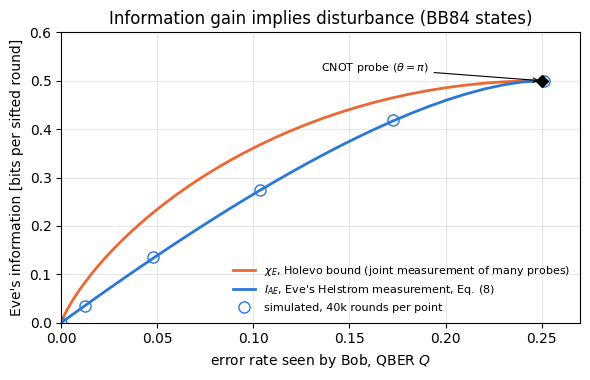

In [7]:
# ==============================================================================
# FIGURE: the information-disturbance trade-off of the probe attack
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.0, 3.9))
ax.plot(curve[:, 0], curve[:, 2], color=PALETTE[1], lw=2,
        label="$\\chi_E$, Holevo bound (joint measurement of many probes)")
ax.plot(curve[:, 0], curve[:, 1], color=PALETTE[0], lw=2, label="$I_{AE}$, Eve's Helstrom measurement, Eq. (8)")
ax.plot(mc[:, 0], mc[:, 1], MARKERS[0], color=PALETTE[0], mfc="none", ms=8,
        label=f"simulated, {N_ROUNDS // 1000}k rounds per point")
ax.plot([0.25], [0.5], MARKERS[3], color="k", ms=6)
ax.annotate("CNOT probe ($\\theta=\\pi$)", (0.25, 0.5), xytext=(0.135, 0.52), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("error rate seen by Bob, QBER $Q$"); ax.set_ylabel("Eve's information [bits per sifted round]")
ax.set_xlim(0, 0.27); ax.set_ylim(0, 0.6)
ax.set_title("Information gain implies disturbance (BB84 states)"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

The engine reproduces Eq. (8) at every coupling strength, and the simulated rounds lie on the curve within their
statistical spread. Eve's information starts at zero exactly when Bob sees no errors and grows with the error rate:
at $Q=1.9\,\%$ ($\theta=\pi/4$) her best measurement yields $0.054$ bits per sifted round, at $Q=7.3\,\%$ ($\theta=
\pi/2$) $0.20$ bits, and the full CNOT gives her half a bit per round, all of it from the $Z$-basis rounds, at the
price of $Q=25\,\%$. The Holevo curve lies above: probes kept in a quantum memory and measured jointly are worth
up to $0.30$ bits per round to Eve at $\theta=\pi/2$, but still nothing at $Q=0$. Near the origin
$c=1-4Q$ gives $1-c^2\approx8Q$, and with $1-h(\tfrac12-x)\approx2x^2/\ln2$ the measured information grows
linearly, $I_{AE}\approx2Q/\ln2$, while the Holevo quantity, $\chi_E=\tfrac12h(1-2Q)=\tfrac12h(2Q)$, rises with
infinite slope. A small error rate does not mean a negligible leak, which is
why the security analysis of quantum key distribution subtracts a bound on Eve's information instead of ignoring
small error rates. The wrong control makes the role of nonorthogonality
visible: with $Z$-basis signals only, the CNOT gives Eve the whole bit and Bob sees no error at all.

## 6. Entanglement, LOCC and monogamy

### 6.1 Bell states, ebits and LOCC

The four Bell states $\vert\Phi^\pm\rangle=(\vert00\rangle\pm\vert11\rangle)/\sqrt2$ and
$\vert\Psi^\pm\rangle=(\vert01\rangle\pm\vert10\rangle)/\sqrt2$ form an orthonormal basis of two qubits, and each half
of a Bell pair alone is maximally mixed, $\mathbb 1/2$. A shared copy of $\vert\Phi^+\rangle$ is called one **ebit**.
Its outcomes agree in the $Z$ basis and in the $X$ basis at once, which no pair of classically correlated bits can do.
[Notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb), Sections 3–4, derives these
correlations, and [notebook
21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb), Section 3, the Bell
measurement circuit.

Two separated laboratories that may each do anything to their own qubits and talk over a telephone line, but cannot
exchange qubits, are restricted to **local operations and classical communication**, LOCC. LOCC cannot create
entanglement from product states and cannot increase it on average, so shared entanglement is a resource that must be
distributed by sending quantum systems, and that protocols such as teleportation use up.

**No-signalling.** Whatever Alice does to her half, a channel with Kraus operators $K_k$ or a measurement whose
outcome Bob does not learn, Bob's reduced state is unchanged:

$$\textstyle\sum_k{\rm Tr}_A\big[(K_k\otimes\mathbb 1)\rho_{AB}(K_k^\dagger\otimes\mathbb 1)\big]
={\rm Tr}_A\big[(\sum_kK_k^\dagger K_k\otimes\mathbb 1)\rho_{AB}\big]={\rm Tr}_A\rho_{AB}=\rho_B, \tag{9}$$

by the cyclic property of the trace on $A$ and $\sum_kK_k^\dagger K_k=\mathbb 1$. Entanglement creates correlations
without any signal. [Notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb), Section 7,
shows the same statement inside teleportation, where Bob's qubit stays maximally mixed until the classical bits
arrive.

### 6.2 Monogamy of entanglement

Maximal entanglement cannot be shared. **Theorem.** If the state $\rho_{AB}$ of Alice and Bob is pure, every state
$\rho_{ABE}$ of a larger system that reduces to it is a product, $\rho_{ABE}=\rho_{AB}\otimes\rho_E$.

**Proof idea.** Every mixed state is the reduced state of a pure state of a larger system, its **purification**
(notebook 07, Section 4). Purify $\rho_{ABE}$ with a further system $R$ into a pure state
$\vert\Omega\rangle_{ABER}$. Its
reduced state on $AB$ is the pure state $\vert\phi\rangle_{AB}$, so the Schmidt decomposition of $\vert\Omega\rangle$
across the cut $AB\,\vert\,ER$ has a single term (notebook 06, Section 6):

$$\vert\Omega\rangle=\vert\phi\rangle_{AB}\otimes\vert\eta\rangle_{ER}. \tag{10}$$

Tracing out $R$ gives $\vert\phi\rangle\langle\phi\vert\otimes\rho_E$. $\square$

If Alice and Bob verify that they hold exactly $\vert\Phi^+\rangle$, Eve is therefore uncorrelated with their pair,
whatever she did while it was distributed. In practice they verify only that the pair is close to
$\vert\Phi^+\rangle$, with a **fidelity** $F=\langle\Phi^+\vert\rho_{AB}\vert\Phi^+\rangle$ slightly below one, and
the statement must become quantitative. Assume the worst case, in which Eve holds the purification of $\rho_{AB}$, so
that $\rho_{ABE}$ is pure. Then $S(E)=S(AB)$, because the two halves of a pure state have the same Schmidt
coefficients. The **quantum mutual information** $I(X{:}Y)=S(X)+S(Y)-S(XY)$ is the formula of notebook 50, Eq. (10),
with von Neumann entropies, and Eve's mutual information with the pair is $I(AB{:}E)=S(AB)+S(E)-S(ABE)=2S(AB)$. The
largest eigenvalue of $\rho_{AB}$ is at least $F=\langle\Phi^+\vert\rho_{AB}\vert\Phi^+\rangle$, and among four
probabilities whose largest is at least $F\geq1/4$ the entropy is maximal when the largest equals $F$ and the other
three share $1-F$ equally. Hence

$$I(A{:}E)\;\leq\;I(AB{:}E)=2S(AB)\;\leq\;2\big[h(F)+(1-F)\log_23\big], \tag{11}$$

where the first inequality says that discarding $B$ cannot increase the correlations with $E$. The bound vanishes as
$F\to1$. A finer, entanglement-based version of monogamy for three qubits is the inequality of Coffman, Kundu and
Wootters (2000). The next cell builds random extensions: a four-qubit pure state of $A$, $B$ and a two-qubit Eve
(enough to purify any two-qubit state), $\vert\Omega\rangle\propto\cos t\,\vert\Phi^+\rangle_{AB}\vert00\rangle_E+
\sin t\,\vert\xi\rangle$ with a Haar-random $\vert\xi\rangle$, for $40$ random $\vert\xi\rangle$ and $25$ values of
$t$. The wrong control is the GHZ state $(\vert000\rangle+\vert111\rangle)/\sqrt2$ with Eve holding the third qubit:
Alice and Bob agree perfectly in the $Z$ basis, but their pair has $F=1/2$, and Eve knows everything.

F in [0.99, 1.00]:   85 states, largest I(A:E) = 0.0753, largest I(AB:E) = 0.1503, bound Eq. (11) at F = 0.99: 0.1933
F in [0.95, 0.99]:   93 states, largest I(A:E) = 0.2940, largest I(AB:E) = 0.5832, bound Eq. (11) at F = 0.95: 0.7313
F in [0.90, 0.95]:   75 states, largest I(A:E) = 0.5334, largest I(AB:E) = 1.0596, bound Eq. (11) at F = 0.90: 1.2550
F in [0.70, 0.90]:  189 states, largest I(A:E) = 1.1139, largest I(AB:E) = 2.1880, bound Eq. (11) at F = 0.70: 2.7136
F in [0.50, 0.70]:  169 states, largest I(A:E) = 1.4313, largest I(AB:E) = 2.8158, bound Eq. (11) at F = 0.50: 3.5850

wrong control, GHZ shared with Eve: F = 0.500, I(A:E) = 1.000 bit, I(AB:E) = 2.000 bits


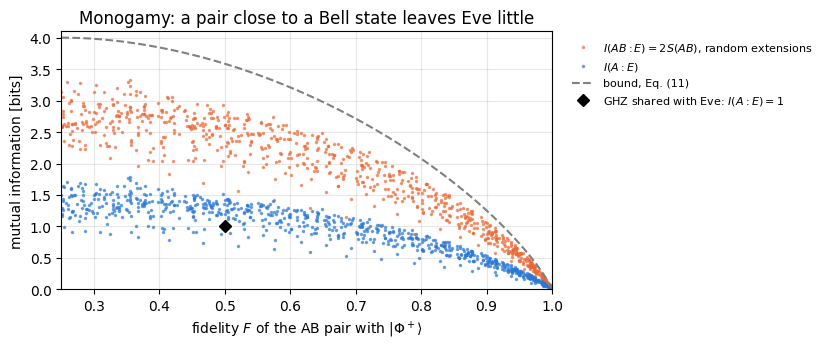

In [8]:
# ==============================================================================
# Eqs. (10)-(11): monogamy -- random extensions of a near-Bell pair to a 2-qubit Eve
# ==============================================================================
PHI_PLUS = bell_state("phi+")
base = jnp.einsum("ab,cd->abcd", PHI_PLUS, product_state("00"))       # |Phi+>_AB |00>_E, qubits A, B, E1, E2


@jax.jit
def _correlations(omega):
    r_ab = rdm(omega, [0, 1])
    F = jnp.real(jnp.vdot(PHI_PLUS.reshape(-1), r_ab @ PHI_PLUS.reshape(-1)))
    S_A, S_E, S_AE, S_AB = (von_neumann_entropy(rdm(omega, k)) for k in ([0], [2, 3], [0, 2, 3], [0, 1]))
    return jnp.stack([F, S_A + S_E - S_AE, 2 * S_AB])


def correlations_with_eve(omega):
    """F, I(A:E), I(AB:E) for a pure state of A, B, E1, E2 (qubits 0, 1, 2, 3), compiled with jax.jit."""
    return tuple(float(x) + 0.0 for x in _correlations(jnp.asarray(omega, dtype=CDTYPE)))


rows = []
for j in range(40):
    xi = haar_state(key_for(100 + j), 4)
    for t in np.linspace(0, np.pi / 2, 25):
        omega = np.cos(t) * base + np.sin(t) * xi
        rows.append(correlations_with_eve(omega / jnp.linalg.norm(omega)))
rows = np.array(rows)
F_r, IAE_r, IABE_r = rows.T
bound = 2 * (h2(F_r) + (1 - F_r) * np.log2(3))                          # Eq. (11)
ok = F_r >= 0.25
assert np.all(IAE_r <= IABE_r + 1e-9)                                   # discarding B cannot increase I
assert np.all(IABE_r[ok] <= bound[ok] + 1e-9)                           # Eq. (11)
assert np.all(IABE_r[F_r > 1 - 1e-12] < 1e-9)                           # exact Bell pair: Eve uncorrelated, Eq. (10)
for lo, hi in [(0.99, 1.0), (0.95, 0.99), (0.9, 0.95), (0.7, 0.9), (0.5, 0.7)]:
    sel = (F_r >= lo) & (F_r < hi + 1e-12)
    print(f"F in [{lo:.2f}, {hi:.2f}]: {sel.sum():4d} states, largest I(A:E) = {IAE_r[sel].max():.4f}, "
          f"largest I(AB:E) = {IABE_r[sel].max():.4f}, bound Eq. (11) at F = {lo:.2f}: "
          f"{2 * (h2(lo) + (1 - lo) * np.log2(3)):.4f}")

# wrong control: GHZ, Eve holds the third qubit (and E2 is idle)
ghz4 = jnp.zeros((2,) * 4, dtype=CDTYPE).at[0, 0, 0, 0].set(2**-0.5).at[1, 1, 1, 0].set(2**-0.5)
F_g, IAE_g, IABE_g = correlations_with_eve(ghz4)
print(f"\nwrong control, GHZ shared with Eve: F = {F_g:.3f}, I(A:E) = {IAE_g:.3f} bit, I(AB:E) = {IABE_g:.3f} bits")
assert abs(F_g - 0.5) < TOL and abs(IAE_g - 1) < 1e-9

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.plot(F_r, IABE_r, ".", color=PALETTE[1], ms=3, alpha=0.6, label="$I(AB{:}E)=2S(AB)$, random extensions")
ax.plot(F_r, IAE_r, ".", color=PALETTE[0], ms=3, alpha=0.6, label="$I(A{:}E)$")
Fg = np.linspace(0.25, 1, 301)
ax.plot(Fg, 2 * (h2(Fg) + (1 - Fg) * np.log2(3)), "--", color="gray", lw=1.5, label="bound, Eq. (11)")
ax.plot([F_g], [IAE_g], MARKERS[3], color="k", ms=6, label="GHZ shared with Eve: $I(A{:}E)=1$")
ax.set_xlabel("fidelity $F$ of the AB pair with $\\vert\\Phi^+\\rangle$"); ax.set_ylabel("mutual information [bits]")
ax.set_xlim(0.25, 1.0); ax.set_ylim(0, 4.1)
ax.set_title("Monogamy: a pair close to a Bell state leaves Eve little")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout(); plt.show()

For the exact Bell pair Eve's correlations vanish to machine precision, as Eq. (10) requires, and every one of the
$1000$ random extensions obeys Eq. (11). As the fidelity approaches one, both mutual informations are squeezed to
zero. Above $F=0.99$ no extension gives Eve more than $0.075$ bits of mutual information with Alice's half and
$0.15$ bits with the pair, against the bound $0.19$ of Eq. (11); between $F=0.9$ and $0.95$ she can still hold up to
$0.53$ bits with Alice's half. Near $F=1$ the bound is about $30\,\%$ above the largest value found, and at low
fidelity it is loose. The GHZ control shows what the fidelity test protects against. Alice's and Bob's $Z$ results
agree perfectly, yet Eve holds a third perfect copy of the same bit, $I(A{:}E)=1$. The pair fails the fidelity test,
$F=1/2$, because its $X$ results are uncorrelated. Agreement in two complementary bases is what excludes a third
party; entanglement-based quantum key distribution checks exactly this.

## 7. Resource accounting

Teleportation sends an unknown qubit with one ebit and two classical bits, and superdense coding sends two
classical bits with one ebit and one qubit. Written as resource inequalities, "the left side can simulate the right
side",

$$1\ \text{ebit}+2\ \text{bits}\;\geq\;1\ \text{qubit},\qquad1\ \text{ebit}+1\ \text{qubit}\;\geq\;2\ \text{bits}.
\tag{12}$$

The ebit is used up in both. Neither classical bits alone (no-cloning, Section 4) nor entanglement alone
(no-signalling, Eq. (9)) can replace a qubit. Teleportation is derived in
[notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb), Sections 4–7, and superdense
coding with its resource ledger in
[notebook 21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb), Section 12.
The second inequality returns in Section 9.3 as the entanglement-assisted capacity of a noiseless qubit.

## 8. Quantum channels

### 8.1 Definition and Kraus form

A classical channel (notebook 50, Section 5.1) is a matrix of transition probabilities that maps input distributions
to output distributions. A **quantum channel** maps density matrices to density matrices: a linear map
$\rho\mapsto\mathcal E(\rho)$ that keeps every state a state, including when it acts on one half of an entangled
pair. Every such map can be written with **Kraus operators** $K_k$,

$$\mathcal E(\rho)=\sum_kK_k\,\rho\,K_k^\dagger,\qquad\sum_kK_k^\dagger K_k=\mathbb 1 . \tag{13}$$

The Kraus form follows from Figure 1b: the signal interacts unitarily with an environment that starts in a fixed
state, and the environment is then traced out. [Notebook
07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb), Section 7, derives Eq. (13) this way,
Section 8 implements it as one einsum (`apply_kraus_dm`), and Section 9 shows the standard channels on the Bloch
sphere. For communication the environment has a second role: whatever information leaks out of the signal goes into
it, and the cautious assumption is that Eve holds the environment.

### 8.2 Four channels and their Bloch pictures

A qubit state is $\rho=\tfrac12(\mathbb 1+\mathbf r\cdot\boldsymbol\sigma)$ with Bloch vector $\mathbf r$, and a
one-qubit channel acts on $\mathbf r$ as an affine map (notebook 07, Section 9.3). Four channels matter in this
chapter.

* **Depolarising**, $\mathcal E(\rho)=(1-p)\rho+\frac p3(X\rho X+Y\rho Y+Z\rho Z)$: each Pauli error with probability
  $p/3$. The Bloch ball shrinks uniformly, $\mathbf r\to(1-\tfrac{4p}3)\mathbf r$, and is a point at $p=3/4$.
* **Dephasing**, $\mathcal E(\rho)=(1-p)\rho+pZ\rho Z$: a phase error with probability $p$. Coherences shrink,
  $(r_x,r_y,r_z)\to((1-2p)r_x,(1-2p)r_y,r_z)$, and the poles $\vert0\rangle$, $\vert1\rangle$ are untouched.
* **Amplitude damping**: the excited state $\vert1\rangle$ decays to $\vert0\rangle$ with probability $\gamma$, as in
  spontaneous emission of a photon. The Kraus operators are the no-decay operator $K_0=\vert0\rangle\langle0\vert+
  \sqrt{1-\gamma}\,\vert1\rangle\langle1\vert$ and the jump $K_1=\sqrt\gamma\,\vert0\rangle\langle1\vert$, which takes
  $\vert1\rangle$ to $\vert0\rangle$; these are the same operators as the engine's `kraus_amplitude_damping` of
  [notebook 07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb). The ball shrinks and moves towards the north pole,
  $(r_x,r_y,r_z)\to(\sqrt{1-\gamma}\,r_x,\sqrt{1-\gamma}\,r_y,\gamma+(1-\gamma)r_z)$.
* **Erasure**: with probability $e$ the qubit is lost, and the receiver is told so. The output lives in a larger
  space, the qubit plus an orthogonal "erased" flag:

$$\mathcal E_e(\rho)=(1-e)\,\rho\otimes\vert0\rangle\langle0\vert_{\rm flag}+e\,\vert0\rangle\langle0\vert\otimes
\vert1\rangle\langle1\vert_{\rm flag}. \tag{14}$$

The erasure channel is the quantum version of the binary erasure channel of notebook 50: a photon that is absorbed in
the fibre never reaches the detector, and the missing click tells Bob that it was lost. On the qubits that arrive, the
Bloch vector is intact. Equation (14) is a channel from one qubit to two (data and flag) with three Kraus operators
acting on the data qubit and a flag qubit prepared in $\vert0\rangle$:
$K_0=\sqrt{1-e}\;\mathbb 1\otimes\mathbb 1$, $K_1=\sqrt e\,\vert0\rangle\langle0\vert\otimes X$ and
$K_2=\sqrt e\,\vert0\rangle\langle1\vert\otimes X$. The flag $X$ marks the erasure, and the data qubit is reset to
$\vert0\rangle$; one checks $\sum_kK_k^\dagger K_k=(1-e)\mathbb 1+e\,(\vert0\rangle\langle0\vert+\vert1\rangle
\langle1\vert)\otimes X^2=\mathbb 1$.

The next cell builds the four channels, the first two from the engine and the last two explicitly, checks
completeness, applies them with `apply_kraus_dm` to pure states around the $x$–$z$ great circle of the Bloch sphere,
and compares the output Bloch vectors with the formulas above.

depolarising      : 4 Kraus operators of size 2, max |sum K^dag K - 1| = 0.0e+00
dephasing         : 2 Kraus operators of size 2, max |sum K^dag K - 1| = 0.0e+00
amplitude damping : 2 Kraus operators of size 2, max |sum K^dag K - 1| = 0.0e+00
erasure           : 3 Kraus operators of size 4, max |sum K^dag K - 1| = 0.0e+00


Bloch maps of Section 8.2 reproduced on 73 pure states: largest deviation 2.2e-16


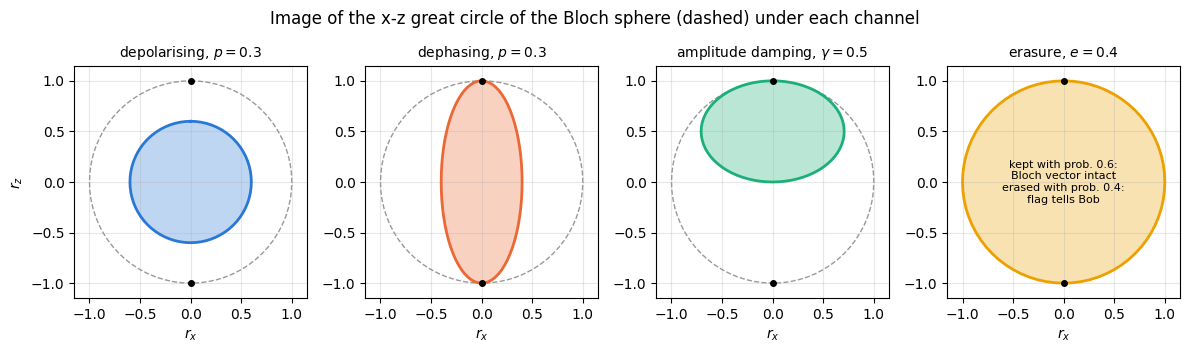

In [9]:
# ==============================================================================
# Eqs. (13)-(14): four channels, their completeness and their Bloch maps
# ==============================================================================
DECAY = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)                      # |0><1|: takes |1> to |0>


def kraus_amp_damp(g):
    """Amplitude damping: K0 = |0><0| + sqrt(1-g)|1><1| (no decay), K1 = sqrt(g)|0><1| (decay |1> -> |0>)."""
    K0 = jnp.array([[1, 0], [0, np.sqrt(1 - g)]], dtype=CDTYPE)
    return jnp.stack([K0, np.sqrt(g) * DECAY])


def kraus_erasure(e):
    """Eq. (14) as three 4x4 Kraus operators on (data, flag), flag prepared in |0>:
    sqrt(1-e) 1, sqrt(e) |0><0| (x) X, sqrt(e) |0><1| (x) X."""
    P0_ = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)
    return jnp.stack([np.sqrt(1 - e) * jnp.eye(4, dtype=CDTYPE),
                      np.sqrt(e) * jnp.kron(P0_, X), np.sqrt(e) * jnp.kron(DECAY, X)])


def completeness(K):
    d = K.shape[-1]
    return float(jnp.max(jnp.abs(jnp.einsum("kji,kjl->il", jnp.conj(K), K) - jnp.eye(d))))


for name, K in [("depolarising", kraus_depolarizing(0.3)), ("dephasing", kraus_dephasing(0.3)),
                ("amplitude damping", kraus_amp_damp(0.3)), ("erasure", kraus_erasure(0.3))]:
    print(f"{name:18s}: {K.shape[0]} Kraus operators of size {K.shape[1]}, "
          f"max |sum K^dag K - 1| = {completeness(K):.1e}")
    assert completeness(K) < TOL


def through_erasure(rho_data, e):
    """Send a one-qubit density matrix through Eq. (14); returns the (data, flag) density tensor."""
    rho = jnp.einsum("ab,cd->acbd", rho_data, proj(KET0))                # data (x) |0><0|_flag, tensor (2,2,2,2)
    return kraus_apply(rho, kraus_erasure(e), [0, 1])


P_NOISE, G_AD, E_ER = 0.3, 0.5, 0.4
angles = np.linspace(0, 2 * np.pi, 73)
images = {k: [] for k in ("depolarising", "dephasing", "amplitude damping", "erasure")}
max_err = 0.0
for a in angles:
    r_in = np.array([np.sin(a), 0.0, np.cos(a)])
    rho_in = proj(ket(a))
    r_dep = bloch(kraus_apply(rho_in, kraus_depolarizing(P_NOISE), [0]))
    r_dph = bloch(kraus_apply(rho_in, kraus_dephasing(P_NOISE), [0]))
    r_ad = bloch(kraus_apply(rho_in, kraus_amp_damp(G_AD), [0]))
    out_er = through_erasure(rho_in, E_ER)
    p_kept = float(jnp.real(dm_matrix(rdm_dm(out_er, [1]))[0, 0]))       # probability of the flag |0>
    rho_kept = dm_matrix(out_er)[0::2, 0::2] / p_kept                     # data qubit given flag 0 (rows: data, flag)
    r_er = bloch(rho_kept)
    expected = [(1 - 4 * P_NOISE / 3) * r_in,
                np.array([(1 - 2 * P_NOISE) * r_in[0], 0.0, r_in[2]]),
                np.array([np.sqrt(1 - G_AD) * r_in[0], 0.0, G_AD + (1 - G_AD) * r_in[2]]),
                r_in]
    for key_, r_out, r_exp in zip(images, (r_dep, r_dph, r_ad, r_er), expected):
        images[key_].append(r_out)
        max_err = max(max_err, float(np.max(np.abs(r_out - r_exp))))
    assert abs(p_kept - (1 - E_ER)) < TOL
print(f"Bloch maps of Section 8.2 reproduced on 73 pure states: largest deviation {max_err:.1e}")
assert max_err < TOL

fig, axes = plt.subplots(1, 4, figsize=(12, 3.3))
titles = [f"depolarising, $p={P_NOISE}$", f"dephasing, $p={P_NOISE}$", f"amplitude damping, $\\gamma={G_AD}$",
          f"erasure, $e={E_ER}$"]
for ax, (name, pts), title, col in zip(axes, images.items(), titles, PALETTE):
    pts = np.array(pts)
    ax.plot(np.sin(angles), np.cos(angles), color="0.6", lw=1, ls="--")
    ax.fill(pts[:, 0], pts[:, 2], color=col, alpha=0.3, lw=0)
    ax.plot(pts[:, 0], pts[:, 2], color=col, lw=2)
    ax.plot([0], [1], "o", color="k", ms=4); ax.plot([0], [-1], "o", color="k", ms=4)
    ax.set_aspect("equal"); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel("$r_x$"); ax.set_title(title, fontsize=10)
axes[0].set_ylabel("$r_z$")
axes[3].text(0, 0, f"kept with prob. {1 - E_ER:.1f}:\nBloch vector intact\nerased with prob. {E_ER}:\nflag tells Bob",
             ha="center", va="center", fontsize=8)
fig.suptitle("Image of the x-z great circle of the Bloch sphere (dashed) under each channel", y=1.0)
plt.tight_layout(); plt.show()

All four channels are complete, and the Bloch vectors of $73$ pure inputs follow the affine maps of Section 8.2 to
machine precision. The pictures show four different kinds of damage. The depolarising channel shrinks the circle
uniformly, by $1-4p/3=0.6$ at $p=0.3$, so every direction is equally degraded. Dephasing squeezes it into an ellipse
along $z$: the poles, which carry a classical bit, survive untouched, while superpositions lose their phase. Amplitude
damping shrinks the circle and moves it towards $\vert0\rangle$; at $\gamma=0.5$ the image of $\vert1\rangle$ sits at
the centre. The erasure channel either delivers the state intact or announces the loss. Section 9 shows that these
differences decide how many classical bits and how many qubits each channel carries.

## 9. Capacities of quantum channels

The **capacity** of a classical channel is the largest rate, in bits per use, at which information can be sent with
an error probability that goes to zero over many uses, and Shannon's theorem equates it to the maximal mutual
information (notebook 50, Section 5.3). A quantum channel has several capacities, because it can be asked to carry
different things: classical bits, qubits, or classical bits with the help of entanglement shared in advance. Each is
defined operationally in the same way, as the best rate with vanishing error over many uses of the channel, and each
has its own formula.

### 9.1 Classical capacity and the Holevo bound

To send a classical message, Alice encodes the letter $i$, chosen with probability $p_i$, into a state $\rho_i$ and
sends it through the channel; Bob receives $\mathcal E(\rho_i)$ and measures. Holevo (1973) proved that the mutual
information between Alice's letter and any measurement result of Bob is bounded by the **Holevo quantity** of the
received ensemble,

$$I(A{:}B)\;\leq\;\chi=S\Big(\sum_ip_i\,\mathcal E(\rho_i)\Big)-\sum_ip_i\,S\big(\mathcal E(\rho_i)\big)\;\leq\;
\log_2d , \tag{15}$$

where $S$ is the von Neumann entropy and $d$ the dimension of the output. [Notebook
21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb), Section 13,
introduces this bound for superdense coding. For a qubit $d=2$, so **one qubit carries at most one classical bit**.
The Holevo quantity is also achievable: if Alice uses product states over many channel uses and Bob measures the whole
block collectively, the maximum of $\chi$ over ensembles is an achievable rate, the Holevo–Schumacher–Westmoreland
theorem (Holevo 1998; Schumacher and Westmoreland 1997). In general the classical capacity requires a further
maximisation over entangled inputs across many uses; for the channels below the single-use value is already the
answer.

We write $\chi^\ast$ for the maximum of $\chi$ over all input ensembles. For the depolarising channel it can be
found by hand. Every pure input has a Bloch vector of length one,
so every output has length $\lambda=1-4p/3$ and eigenvalues $(1\pm\lambda)/2$; its entropy is $h\big((1-\lambda)/2
\big)=h(2p/3)$, and mixed inputs give at least as much. The average output has entropy at most $1$. Hence
$\chi\leq1-h(2p/3)$ for every ensemble, and the ensemble $\{\vert0\rangle,\vert1\rangle\}$ with equal weights reaches
it, because the average output is $\mathbb 1/2$:

$$\chi^\ast_{\rm depol}=1-h\big(\tfrac{2p}3\big). \tag{16}$$

This is the capacity of a binary symmetric channel with flip probability $2p/3$: sending $\vert0\rangle$ or
$\vert1\rangle$ and measuring $Z$, the bit flips when the error is $X$ or $Y$. King (2003) proved that no entangled
input and no collective measurement does better, so Eq. (16) is the classical capacity of the depolarising channel.
For the dephasing channel $\chi^\ast=1$ at every $p$, the largest value Eq. (15) allows, since $\vert0\rangle$ and
$\vert1\rangle$ pass unchanged. For the erasure channel the inputs $\vert0\rangle$, $\vert1\rangle$ give $\chi=1-e$,
the capacity of the classical erasure channel, and Bennett, DiVincenzo and Smolin (1997) showed that this is the
classical capacity. The next cell
computes $\chi$ with the engine for pairs of pure input states at every angle and weight, and for $500$ random
ensembles of four mixed states, and checks Eqs. (15)–(16). The wrong control is a pair of nonorthogonal inputs,
$\vert0\rangle$ and $\vert+\rangle$, which stays below the maximum.

In [10]:
# ==============================================================================
# Eqs. (15)-(16): Holevo quantity of the depolarising channel, scanned over input ensembles
# ==============================================================================
def holevo_chi(states, probs, channel):
    """Eq. (15): chi = S(sum_i p_i E(rho_i)) - sum_i p_i S(E(rho_i)); `channel` maps a 2x2 matrix to a matrix."""
    outs = [channel(r) for r in states]
    avg = sum(p * o for p, o in zip(probs, outs))
    return S_vn(avg) - sum(p * S_vn(o) for p, o in zip(probs, outs))


def depol(p):
    return lambda r: kraus_apply(r, kraus_depolarizing(p), [0])


p_dep = 0.1
chi_star = 1 - h2(2 * p_dep / 3)                                          # Eq. (16)
best = 0.0
for ang in np.linspace(0, np.pi, 37):                                     # angle between the two Bloch vectors
    for w in np.linspace(0.05, 0.95, 19):
        best = max(best, holevo_chi([proj(KET0), proj(ket(ang))], [w, 1 - w], depol(p_dep)))
print(f"depolarising p = {p_dep}: Eq. (16) chi* = 1 - h(2p/3) = {chi_star:.6f}; "
      f"best two-state ensemble on the grid: {best:.6f}")
assert abs(best - chi_star) < TOL                                         # reached by |0>, |1> at weight 1/2

rng = np.random.default_rng(int(jax.random.randint(key_for(3), (), 0, 2**31 - 1)))
worst_gap = np.inf
keys4 = jax.vmap(lambda j: jax.random.fold_in(key_for(4), j))(jnp.arange(2_000))
haar_kets = jax.vmap(lambda k: haar_state(k, 1))(keys4)                    # 2000 Haar-random qubit states at once
for i in range(500):
    sts = []
    for k in range(4):
        s_mix = rng.uniform(0.5, 1)
        sts.append(s_mix * proj(haar_kets[4 * i + k]) + (1 - s_mix) * I2 / 2)   # a random mixed state
    pr = rng.dirichlet(np.ones(4))
    chi = holevo_chi(sts, pr, depol(p_dep))
    worst_gap = min(worst_gap, chi_star - chi)
print(f"500 random ensembles of four mixed states: smallest gap chi* - chi = {worst_gap:.4f} (must be >= 0)")
assert worst_gap >= -TOL

chi_bad = holevo_chi([proj(KET0), proj(KETP)], [0.5, 0.5], depol(p_dep))
print(f"wrong control, inputs |0> and |+>: chi = {chi_bad:.4f} < chi* = {chi_star:.4f}")
assert chi_bad < chi_star - 0.1

# dephasing and erasure: chi* = 1 and 1 - e with the inputs |0>, |1>
for p in (0.1, 0.3, 0.5):
    c_dph = holevo_chi([proj(KET0), proj(KET1)], [0.5, 0.5], lambda r: kraus_apply(r, kraus_dephasing(p), [0]))
    c_er = holevo_chi([proj(KET0), proj(KET1)], [0.5, 0.5], lambda r: dm_matrix(through_erasure(r, p)))
    print(f"p = e = {p}: chi(dephasing) = {c_dph:.6f}, chi(erasure) = {c_er:.6f} (1 - e = {1 - p:.6f})")
    assert abs(c_dph - 1) < TOL and abs(c_er - (1 - p)) < TOL

depolarising p = 0.1: Eq. (16) chi* = 1 - h(2p/3) = 0.646641; best two-state ensemble on the grid: 0.646641


500 random ensembles of four mixed states: smallest gap chi* - chi = 0.1418 (must be >= 0)
wrong control, inputs |0> and |+>: chi = 0.3556 < chi* = 0.6466
p = e = 0.1: chi(dephasing) = 1.000000, chi(erasure) = 0.900000 (1 - e = 0.900000)
p = e = 0.3: chi(dephasing) = 1.000000, chi(erasure) = 0.700000 (1 - e = 0.700000)
p = e = 0.5: chi(dephasing) = 1.000000, chi(erasure) = 0.500000 (1 - e = 0.500000)


The best of the $703$ two-state ensembles gives exactly $1-h(2p/3)=0.6466$ bits at $p=0.1$, reached by $\vert0\rangle$
and $\vert1\rangle$ with equal weights, and none of the $500$ random ensembles of mixed states exceeds it. Two
nonorthogonal inputs such as $\vert0\rangle$ and $\vert+\rangle$ are a poor code, since they start out partly
indistinguishable (Section 3). Dephasing does not reduce the classical capacity at all, and erasure reduces it exactly
as in the classical erasure channel. None of these numbers exceeds one bit per qubit, as Eq. (15) requires.

### 9.2 Quantum capacity and the coherent information

The **quantum capacity** $Q_{\rm cap}$ is the largest rate, in qubits per channel use, at which unknown quantum
states can be sent with fidelity approaching one. (The subscript keeps it apart from the error rate $Q$ of Section 5.)
Whether a channel preserves unknown states is tested best with entanglement. Alice prepares a pure state
$\vert\psi\rangle_{RA}$ of the signal $A$ and a reference qubit $R$ that never leaves her laboratory, and sends $A$
through the channel to Bob, who receives $B$. If $R$ and $B$ are still entangled, the pair can carry a qubit by
teleportation (Eq. (12)); the classical messages that teleportation needs do not raise the quantum capacity (Bennett,
DiVincenzo, Smolin and Wootters 1996). The amount of quantum information that survives is measured by the
**coherent information** (Schumacher and Nielsen 1996),

$$I_c(\rho_A,\mathcal E)=S(B)-S(RB). \tag{17}$$

Two limits show its meaning. For a noiseless channel and a Bell pair, $RB$ is pure and $B$ is maximally mixed, so
$I_c=1-0=1$. For a channel that replaces every input by $\vert0\rangle$, $B$ is pure and $RB$ is the product of
$\mathbb 1/2$ and $\vert0\rangle\langle0\vert$, so $I_c=0-1=-1$. If the environment $E$ of Figure 1b is included, the
state of $R$, $B$ and $E$ is pure, so $S(RB)=S(E)$ as in Section 6.2, and $I_c=S(B)-S(E)$: what reaches Bob minus
what leaks to the environment, which in cryptography is Eve.

The quantum capacity is the largest coherent information per channel use. In general the inputs must be allowed to
be entangled across $n$ uses of the channel, so that $Q_{\rm cap}=\lim_{n\to\infty}\frac1n\max_\rho I_c(\rho,
\mathcal E^{\otimes n})$ (Lloyd 1997; Shor 2002; Devetak 2005). One use gives a lower bound, $Q_{\rm cap}\geq
\max_{\rho_A}I_c(\rho_A,\mathcal E)$, and for two of our channels this bound is already the capacity: Bennett,
DiVincenzo and Smolin (1997) found the erasure capacity, and Devetak and Shor (2005) showed that for dephasing the
formula reduces to a single use. A capacity cannot be negative, while $I_c$ can, hence the $\max(0,\cdot)$:

$$Q_{\rm cap}({\rm erasure})=\max(0,\,1-2e),\qquad Q_{\rm cap}({\rm dephasing})=1-h(p). \tag{18}$$

Both follow from Eq. (17) with a Bell pair as input. We use that a mixture with weights $1-e$ and $e$ of two states
with orthogonal supports has entropy $h(e)+(1-e)S_1+eS_2$. For erasure, $\rho_{RB}$ is
$\vert\Phi^+\rangle\langle\Phi^+\vert$ with an unset flag with probability $1-e$ ($S_1=0$), and
$\tfrac12\mathbb 1_R\otimes\vert0\rangle\langle0\vert\otimes\vert1\rangle\langle1\vert_{\rm flag}$ otherwise
($S_2=1$); the flag makes the two parts orthogonal, so $S(RB)=h(e)+e$. In the same way $S(B)=h(e)+(1-e)$, and
$I_c=1-2e$. For dephasing, $\rho_{RB}=(1-p)\vert\Phi^+\rangle\langle\Phi^+\vert+p\,\vert\Phi^-\rangle\langle\Phi^-
\vert$ has entropy $h(p)$ and $\rho_B=\mathbb 1/2$ has entropy $1$. The erasure capacity vanishes at $e=1/2$ for a
reason that is a direct consequence of no-cloning. At $e=1/2$ the environment receives the qubit exactly as often as
Bob does, so the channel treats Bob and the environment symmetrically; if Bob could recover the quantum information,
the environment could recover it too, by the same procedure, and two copies of an unknown state would exist.

For the **depolarising channel** the quantum capacity is not known. The Bell-pair input gives a lower bound, the
**hashing bound** (Bennett, DiVincenzo, Smolin and Wootters 1996). A Pauli error on one half of $\vert\Phi^+\rangle$
turns it into another Bell state (notebook 21, Section 3.1), so $\rho_{RB}$ is a mixture of the four Bell states with
weights $(1-p,p/3,p/3,p/3)$, and

$$Q_{\rm cap}({\rm depolarising})\;\geq\;1-H\big(1-p,\tfrac p3,\tfrac p3,\tfrac p3\big), \tag{19}$$

with $H$ the Shannon entropy of the four weights. It vanishes at $p\approx0.189$. The bound is not the capacity:
codes that use the channel many times at once keep a positive rate slightly beyond this point (DiVincenzo, Shor and
Smolin 1998), which is why the maximisation over $n$ uses cannot be dropped. The next cell computes the coherent
information with the engine: the input is $\sqrt{1-a}\,\vert00\rangle+\sqrt a\,\vert11\rangle$ on $R$ and $A$, the
channel acts on $A$ (with a flag qubit for erasure), and the entropies come from `rdm_dm`. It scans the input
weight $a$ to check that the Bell pair, $a=1/2$, is the best single-use input for these channels, and compares with
Eqs. (18)–(19). As a wrong control, an input without entanglement with $R$ ($a=0$) gives $I_c\leq0$: a classical
state carries no quantum information.

In [11]:
# ==============================================================================
# Eqs. (17)-(19): coherent information with a reference qubit, for three channels
# ==============================================================================
def coherent_info(a, channel_name, p):
    """Eq. (17): I_c = S(B) - S(RB) for the input sqrt(1-a)|00> + sqrt(a)|11> on (R, A), channel on A."""
    psi_ra = jnp.zeros((2, 2), dtype=CDTYPE).at[0, 0].set(np.sqrt(1 - a)).at[1, 1].set(np.sqrt(a))
    if channel_name == "erasure":
        psi = jnp.einsum("ab,c->abc", psi_ra, KET0)                       # qubits R, A, flag
        rho = kraus_apply(to_dm(psi), kraus_erasure(p), [1, 2])
        B, RB = [1, 2], [0, 1, 2]
    else:
        K = {"dephasing": kraus_dephasing, "depolarising": kraus_depolarizing}[channel_name](p)
        rho = kraus_apply(to_dm(psi_ra), K, [1])
        B, RB = [1], [0, 1]
    return S_vn(dm_matrix(rdm_dm(rho, B))) - S_vn(dm_matrix(rdm_dm(rho, RB)))


def hashing(p):
    """Eq. (19): 1 - H(1-p, p/3, p/3, p/3)."""
    return 1 - shannon([1 - p, p / 3, p / 3, p / 3])


a_grid = np.linspace(0, 1, 41)
for name, p, closed in [("erasure", 0.2, 1 - 2 * 0.2), ("dephasing", 0.1, 1 - h2(0.1)),
                        ("depolarising", 0.1, hashing(0.1))]:
    vals = np.array([coherent_info(a, name, p) for a in a_grid])
    print(f"{name:12s} p = {p}: max_a I_c = {vals.max():.6f} at a = {a_grid[vals.argmax()]:.3f}; "
          f"closed form {closed:.6f}; unentangled input a = 0: I_c = {vals[0]:.2e}")
    assert abs(vals.max() - closed) < TOL and abs(a_grid[vals.argmax()] - 0.5) < 1e-12
    assert vals[0] <= TOL                                         # wrong control: no entanglement, no Q_cap

p_curve = np.linspace(0, 0.5, 11)
Ic_er = np.array([coherent_info(0.5, "erasure", p) for p in p_curve])
Ic_dph = np.array([coherent_info(0.5, "dephasing", p) for p in p_curve])
Ic_dep = np.array([coherent_info(0.5, "depolarising", p) for p in p_curve])
assert np.max(np.abs(Ic_er - (1 - 2 * p_curve))) < TOL
assert np.max(np.abs(Ic_dph - (1 - h2(p_curve)))) < 1e-9
assert np.max(np.abs(Ic_dep - np.array([hashing(p) for p in p_curve]))) < 1e-9
lo, hi = 0.15, 0.25                                                      # bisection for the zero of Eq. (19)
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if hashing(mid) > 0 else (lo, mid)
print(f"hashing bound of the depolarising channel vanishes at p = {lo:.4f}")
assert abs(lo - 0.18929) < 1e-4

erasure      p = 0.2: max_a I_c = 0.600000 at a = 0.500; closed form 0.600000; unentangled input a = 0: I_c = -2.13e-14
dephasing    p = 0.1: max_a I_c = 0.531004 at a = 0.500; closed form 0.531004; unentangled input a = 0: I_c = -1.06e-14


depolarising p = 0.1: max_a I_c = 0.372508 at a = 0.500; closed form 0.372508; unentangled input a = 0: I_c = -1.06e-14
hashing bound of the depolarising channel vanishes at p = 0.1893


For all three channels the single-use coherent information is largest for the Bell-pair input, $a=1/2$, and equals
the closed forms: $1-2e=0.6$ for erasure at $e=0.2$, $1-h(0.1)=0.531$ for dephasing at $p=0.1$, and the hashing value
$0.373$ for the depolarising channel at $p=0.1$. An input that is not entangled with the reference, $a=0$, gives
$I_c=0$ for every channel, because Bob then receives the known pure state $\vert0\rangle$ and no quantum information
at all. The coherent information can also be negative, which happens beyond $e=1/2$ for erasure and
beyond $p=0.189$ for the depolarising channel. For erasure the capacity is then zero; for the depolarising channel
the hashing bound gives nothing there, but the true capacity is not known.

### 9.3 Entanglement-assisted classical capacity

If Alice and Bob share unlimited ebits in advance, the classical capacity grows. Superdense coding already shows this
for a noiseless qubit: two bits per qubit instead of one, the second inequality of Eq. (12). Bennett, Shor, Smolin and
Thapliyal (1999; 2002) proved that the **entanglement-assisted capacity** is given by a single-use formula, the
quantum mutual information between the reference and the output, maximised over inputs:

$$C_E=\max_{\rho_A}\big[S(R)+S(B)-S(RB)\big],\qquad C_{E,\rm depol}=2-H\big(1-p,\tfrac p3,\tfrac p3,\tfrac p3\big).
\tag{20}$$

For the depolarising channel the maximum is at the Bell-pair input, which is how Eq. (20) follows from the same
Bell-diagonal state as Eq. (19), with $S(R)=S(B)=1$. The same number, $2-H$, is the dense-coding capacity of a
depolarised shared pair in notebook 21, Section 14.2; here the pair is perfect and the noise sits in the channel. For
the erasure channel the same input gives $C_E=2(1-e)$, twice the unassisted value.

The last cell of this section evaluates all capacities on one grid and draws them against the noise parameter, with
Shannon's capacity $1-h(q)$ of the binary symmetric channel from notebook 50 for comparison.

 p    | BSC 1-h(p) | chi depol | C_E depol | Q_cap deph | Q_cap erasure | hashing depol
 0.00 |   1.0000   |  1.0000   |  2.0000   |   1.0000   |    1.0000     |  1.0000
 0.10 |   0.5310   |  0.6466   |  1.3725   |   0.5310   |    0.8000     |  0.3725
 0.20 |   0.2781   |  0.4335   |  0.9611   |   0.2781   |    0.6000     |  0.0000
 0.30 |   0.1187   |  0.2781   |  0.6432   |   0.1187   |    0.4000     |  0.0000
 0.40 |   0.0290   |  0.1634   |  0.3951   |   0.0290   |    0.2000     |  0.0000
 0.50 |   0.0000   |  0.0817   |  0.2075   |   0.0000   |    0.0000     |  0.0000


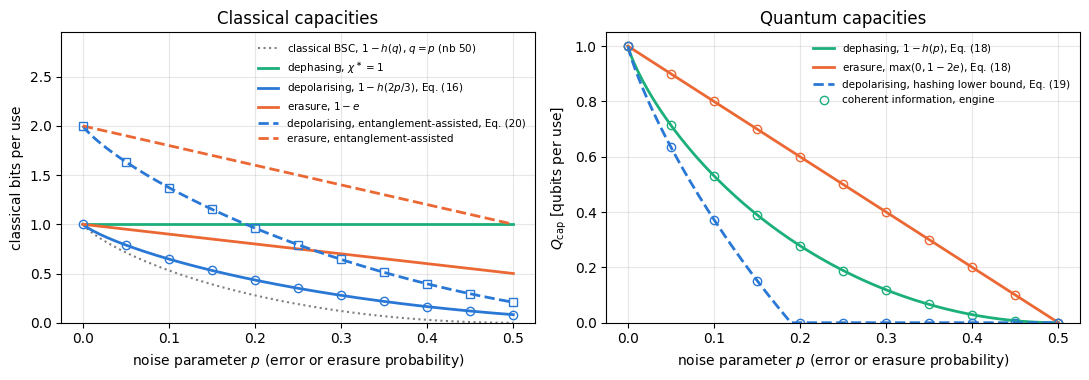

In [12]:
# ==============================================================================
# Eq. (20) and FIGURE: classical, quantum and entanglement-assisted capacities against the noise
# ==============================================================================
def C_E_engine(channel_name, p):
    """Eq. (20) at the Bell-pair input: S(R) + S(B) - S(RB) = 1 + I_c."""
    return 1 + coherent_info(0.5, channel_name, p)


CE_dep = np.array([C_E_engine("depolarising", p) for p in p_curve])
CE_er = np.array([C_E_engine("erasure", p) for p in p_curve])
assert np.max(np.abs(CE_dep - (2 - np.array([shannon([1 - p, p / 3, p / 3, p / 3]) for p in p_curve])))) < 1e-9
assert np.max(np.abs(CE_er - 2 * (1 - p_curve))) < TOL
chi_dep = np.array([holevo_chi([proj(KET0), proj(KET1)], [0.5, 0.5], depol(p)) for p in p_curve])
assert np.max(np.abs(chi_dep - (1 - h2(2 * p_curve / 3)))) < 1e-9
print(" p    | BSC 1-h(p) | chi depol | C_E depol | Q_cap deph | Q_cap erasure | hashing depol")
for i in range(0, 11, 2):
    p = p_curve[i]
    q_dph, q_er, q_dep = (max(float(v[i]), 0.0) + 0.0 for v in (Ic_dph, Ic_er, Ic_dep))   # capacities are >= 0
    print(f" {p:.2f} |   {1 - h2(p):.4f}   |  {chi_dep[i]:.4f}   |  {CE_dep[i]:.4f}   |   {q_dph:.4f}   |    "
          f"{q_er:.4f}     |  {q_dep:.4f}")

pf = np.linspace(0, 0.5, 201)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
ax1.plot(pf, 1 - h2(pf), color="gray", lw=1.5, ls=":", label="classical BSC, $1-h(q)$, $q=p$ (nb 50)")
ax1.plot(pf, np.ones_like(pf), color=PALETTE[2], lw=2, label="dephasing, $\\chi^\\ast=1$")
ax1.plot(pf, 1 - h2(2 * pf / 3), color=PALETTE[0], lw=2, label="depolarising, $1-h(2p/3)$, Eq. (16)")
ax1.plot(pf, 1 - pf, color=PALETTE[1], lw=2, label="erasure, $1-e$")
ax1.plot(pf, 2 - np.array([shannon([1 - p, p / 3, p / 3, p / 3]) for p in pf]), color=PALETTE[0], lw=2, ls="--",
         label="depolarising, entanglement-assisted, Eq. (20)")
ax1.plot(pf, 2 * (1 - pf), color=PALETTE[1], lw=2, ls="--", label="erasure, entanglement-assisted")
ax1.plot(p_curve, chi_dep, MARKERS[0], color=PALETTE[0], mfc="none", ms=6)
ax1.plot(p_curve, CE_dep, MARKERS[1], color=PALETTE[0], mfc="none", ms=6)
ax1.set_xlabel("noise parameter $p$ (error or erasure probability)"); ax1.set_ylabel("classical bits per use")
ax1.set_title("Classical capacities"); ax1.legend(fontsize=7.5, loc="upper right"); ax1.set_ylim(0, 2.95)
ax2.plot(pf, 1 - h2(pf), color=PALETTE[2], lw=2, label="dephasing, $1-h(p)$, Eq. (18)")
ax2.plot(pf, np.maximum(1 - 2 * pf, 0), color=PALETTE[1], lw=2, label="erasure, $\\max(0,1-2e)$, Eq. (18)")
ax2.plot(pf, np.maximum([hashing(p) for p in pf], 0), color=PALETTE[0], lw=2, ls="--",
         label="depolarising, hashing lower bound, Eq. (19)")
ax2.plot(p_curve, Ic_dph, MARKERS[0], color=PALETTE[2], mfc="none", ms=6, label="coherent information, engine")
ax2.plot(p_curve, np.maximum(Ic_er, 0), MARKERS[0], color=PALETTE[1], mfc="none", ms=6)
ax2.plot(p_curve, np.maximum(Ic_dep, 0), MARKERS[0], color=PALETTE[0], mfc="none", ms=6)
ax2.set_xlabel("noise parameter $p$ (error or erasure probability)")
ax2.set_ylabel("$Q_{\\rm cap}$ [qubits per use]"); ax2.set_title("Quantum capacities")
ax2.legend(fontsize=7.5, loc="upper right"); ax2.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

The two panels summarise the section. On the left, the classical capacities of the three quantum channels never
exceed one bit per qubit without help, and the depolarising channel at error probability $p$ behaves exactly like a
binary symmetric channel with flip probability $2p/3$, because only two of the three Pauli errors flip a $Z$ bit.
Dephasing leaves the classical capacity at one bit for every $p$. Shared entanglement doubles the noiseless value to
two bits and raises every curve: at $p=0.1$ the depolarising channel carries $0.647$ bits alone and $1.373$ bits with
entanglement assistance. On the right, the quantum capacities fall much faster: dephasing at $p=0.1$ still carries
a full classical bit per use but only $0.53$ qubits, $1-h(p)$, and at $p=1/2$ it carries a full classical bit and no
qubits at all. Erasure loses its quantum capacity at $e=1/2$, where the no-cloning argument applies, and for the
depolarising channel only the lower bound is drawn. A quantum signal is fragile in a way a classical bit is not:
every error that is invisible on the $Z$ basis still destroys superpositions, and every bit that leaks to the
environment counts against Bob.

## 10. From these rules to quantum key distribution

Quantum key distribution combines two of the rules derived here. Section 5 showed that Eve cannot learn about
nonorthogonal signal states without creating errors; Alice and Bob therefore estimate the error rate on a sample of
their data and bound her information by it. Section 6 showed the same from the side of entanglement: a pair close to a
Bell state, checked in two complementary bases, leaves no room for a third party. The coherent information of
Section 9.2, "what Bob receives minus what leaks to the environment", has the same structure as the secret-key rate
that the next notebook of this chapter derives, $1-2h(Q)$ for BB84: one bit per sifted round, minus the bits spent on
error correction, minus the bits that Eve may know.

## 11. Key takeaways

* **Nonorthogonal states cannot be told apart with certainty.** The best success probability for two equiprobable
  states is $(1+D)/2$ with the trace distance $D$; for $\vert0\rangle$ against $\vert+\rangle$ it is $0.854$, and no
  projective or general measurement in the numerical search did better.
* **No-cloning has practical consequences.** Eve cannot keep a copy of a qubit in transit, and quantum signals cannot
  be amplified. A measure-and-prepare copier reaches fidelity $3/4$ on the BB84 states and no more.
* **Information gain implies disturbance.** An interaction that leaves two nonorthogonal states undisturbed leaves the
  probe in the same state for both. For a controlled-rotation probe on BB84 states Eve's information grows from zero
  with the error rate $Q$, about $2Q/\ln2$ bits per round for small $Q$ (and faster, up to the Holevo quantity, for
  probes stored and measured jointly), up to half a bit per round at $Q=1/4$.
* **Entanglement is monogamous.** A pure state of Alice and Bob is uncorrelated with everything else, and a pair with
  fidelity $F$ to a Bell state gives Eve at most $2[h(F)+(1-F)\log_23]$ bits of mutual information.
* **Quantum channels have Kraus operators and Bloch pictures.** Depolarising, dephasing, amplitude damping and
  erasure shrink, squeeze, shift or delete the Bloch ball.
* **One qubit carries at most one classical bit** (Holevo); the depolarising channel carries $1-h(2p/3)$ bits per use.
  Shared entanglement raises this, up to two bits for a noiseless qubit.
* **Quantum capacities are smaller.** They are given by the coherent information $S(B)-S(RB)$: $1-2e$ for erasure,
  $1-h(p)$ for dephasing, and only bounds for the depolarising channel.

## 12. Exercises

1. ★ **A pair at overlap 3/4.** Bob receives $\vert0\rangle$ or
   $\cos\frac\pi6\vert0\rangle+\sin\frac\pi6\vert1\rangle$ with equal probability. Compute the trace distance and the
   best success probability, and check them with the cell of Section 3.2.
2. ★ **Preparing along the wrong axis.** In the copier of Section 4.1, Eve measures in the $Z$ basis but prepares
   $\vert+\rangle$ after outcome $0$ and $\vert-\rangle$ after outcome $1$. Use Eq. (5) to predict the mean copy
   fidelity on the BB84 states, and confirm it with the engine by changing the prepared state in
   `measure_prepare_copies` (`ket(np.pi / 2)` is $\vert+\rangle$ and `ket(-np.pi / 2)` is $\vert-\rangle$).
3. ★★ **A half-strength probe.** For the attack of Section 5.2 at $\theta=\pi/2$, compute $Q$, $I_{AE}$ and $\chi_E$
   from Eq. (8) by hand, and read them off the cell.
4. ★★ **No-signalling under decay.** Alice and Bob share $\vert\Phi^+\rangle$, and Alice's qubit passes through the
   amplitude-damping channel. Show with Eq. (9) and with the engine that Bob's state stays $\mathbb 1/2$ for every
   $\gamma$, and compute Alice's Bloch vector.
5. ★★ **Classical bits through dephasing.** Explain why the dephasing channel at $p=1/2$ carries one classical bit per
   use and no qubits. Which channel from notebook 50 does it reduce to on the inputs $\vert0\rangle$, $\vert1\rangle$?
6. ★★ **Amplitude damping.** Add `kraus_amp_damp` of Section 8.2 to the dictionary of channels in `coherent_info`
   and find the maximum over $a$ of the single-use coherent information for $\gamma=0.2$ and $\gamma=0.3$. Show,
   using $S(RB)=S(E)$ and the environment state with entries ${\rm Tr}[K_i\rho_AK_j^\dagger]$, that it is
   $\max_a[h((1-\gamma)a)-h(\gamma a)]$ and that it is zero for $\gamma\geq1/2$.
7. ★★★ **Erasure in three numbers.** For the erasure channel at $e=0.25$, compute the classical capacity, the quantum
   capacity and the entanglement-assisted capacity, each from its formula and with the engine, and order them. Explain
   with Eq. (12) where the advantage of $C_E$ over the unassisted classical capacity comes from.

*Check values.* 1: overlap $\vert\langle0\vert\psi\rangle\vert^2=3/4$, $D=1/2$, $P_{\rm succ}=3/4$. 2: with
$\mathbf n=\hat z$ and $\mathbf m=\hat x$, $n_zm_z+n_xm_x=0$, so $\bar F=1/2$: the copies are useless. 3: $c=
\cos(\pi/4)=0.7071$, $Q=0.0732$, $I_{AE}=\tfrac12[1-h(0.1464)]=0.1996$, $\chi_E=\tfrac12h(0.8536)=0.3004$ bits.
4: $\rho_B=\mathbb 1/2$ for every $\gamma$; Alice's Bloch vector is $(0,0,\gamma)$. 5: $\vert0\rangle$ and
$\vert1\rangle$ pass unchanged, so the channel restricted to them is noiseless and $\chi^\ast=1$; at $p=1/2$ the
output of any input is diagonal in the $Z$ basis, the channel destroys every superposition, and
$Q_{\rm cap}=1-h(1/2)=0$; on
$\vert0\rangle$, $\vert1\rangle$ it is the noiseless binary channel, a binary symmetric channel with $q=0$. 6:
$0.506$ at $a\approx0.449$ for
$\gamma=0.2$, $0.328$ at $a\approx0.441$ for $\gamma=0.3$; for $\gamma=1/2$ the two entropies coincide and for
$\gamma>1/2$ the difference is negative. 7: $C=1-e=0.75$, $Q_{\rm cap}=1-2e=0.5$, $C_E=2(1-e)=1.5$, so
$Q_{\rm cap}<C<C_E$; the
advantage is superdense coding, $1\ \text{ebit}+1\ \text{qubit}\geq2$ bits, applied to the fraction $1-e$ of qubits
that arrive, and the ebits are consumed.

## References

* C. W. Helstrom, *Quantum Detection and Estimation Theory* (Academic Press, New York, 1976) — the optimal measurement
  for discriminating two quantum states and its success probability.
* W. K. Wootters and W. H. Zurek, *A single quantum cannot be cloned*, Nature **299**, 802 (1982),
  doi:10.1038/299802a0 — the no-cloning theorem.
* D. Dieks, *Communication by EPR devices*, Phys. Lett. A **92**, 271 (1982), doi:10.1016/0375-9601(82)90084-6 — the
  no-cloning theorem, found independently.
* C. H. Bennett, *Quantum cryptography using any two nonorthogonal states*, Phys. Rev. Lett. **68**, 3121 (1992),
  doi:10.1103/PhysRevLett.68.3121 — any two nonorthogonal states suffice for quantum key distribution.
* C. A. Fuchs and A. Peres, *Quantum-state disturbance versus information gain: Uncertainty relations for quantum
  information*, Phys. Rev. A **53**, 2038 (1996), doi:10.1103/PhysRevA.53.2038 — the trade-off between information
  gain and disturbance, with the optimal detection for two equiprobable nonorthogonal pure states.
* V. Coffman, J. Kundu and W. K. Wootters, *Distributed entanglement*, Phys. Rev. A **61**, 052306 (2000),
  doi:10.1103/PhysRevA.61.052306 — the trade-off between the entanglement of one qubit with two others.
* A. S. Holevo, *Bounds for the quantity of information transmitted by a quantum communication channel*, Problems of
  Information Transmission **9**(3), 177–183 (1973) — the Holevo bound.
* A. S. Holevo, *The capacity of the quantum channel with general signal states*, IEEE Trans. Inf. Theory **44**, 269
  (1998), doi:10.1109/18.651037 — the classical capacity with product inputs equals the maximal Holevo quantity.
* B. Schumacher and M. D. Westmoreland, *Sending classical information via noisy quantum channels*, Phys. Rev. A
  **56**, 131 (1997), doi:10.1103/PhysRevA.56.131 — the same result, obtained independently.
* C. King, *The capacity of the quantum depolarizing channel*, IEEE Trans. Inf. Theory **49**, 221 (2003),
  doi:10.1109/TIT.2002.806153 — the classical capacity of the depolarising channel, achieved with orthonormal product
  states and product measurements.
* B. Schumacher and M. A. Nielsen, *Quantum data processing and error correction*, Phys. Rev. A **54**, 2629 (1996),
  doi:10.1103/PhysRevA.54.2629 — the coherent information.
* S. Lloyd, *Capacity of the noisy quantum channel*, Phys. Rev. A **55**, 1613 (1997), doi:10.1103/PhysRevA.55.1613 —
  the quantum capacity and codes that attain it.
* P. W. Shor, *The quantum channel capacity and coherent information*, lecture notes, MSRI Workshop on Quantum
  Computation (Berkeley, 2002) — an independent proof that the regularised coherent information is achievable.
* I. Devetak, *The private classical capacity and quantum capacity of a quantum channel*, IEEE Trans. Inf. Theory
  **51**, 44 (2005), doi:10.1109/TIT.2004.839515 — a proof of the quantum channel coding theorem through the private
  capacity.
* I. Devetak and P. W. Shor, *The capacity of a quantum channel for simultaneous transmission of classical and quantum
  information*, Commun. Math. Phys. **256**, 287 (2005), doi:10.1007/s00220-005-1317-6 — single-letter formulas for
  dephasing channels.
* C. H. Bennett, D. P. DiVincenzo and J. A. Smolin, *Capacities of quantum erasure channels*, Phys. Rev. Lett. **78**,
  3217 (1997), doi:10.1103/PhysRevLett.78.3217 — the quantum and classical capacities of the erasure channel, and the
  remark that only bounds are known for the depolarising channel.
* C. H. Bennett, D. P. DiVincenzo, J. A. Smolin and W. K. Wootters, *Mixed-state entanglement and quantum error
  correction*, Phys. Rev. A **54**, 3824 (1996), doi:10.1103/PhysRevA.54.3824 — hashing codes that reach the rate
  $1-S$, with $S$ the entropy of the errors, and the result that forward classical communication does not raise the
  quantum capacity.
* D. P. DiVincenzo, P. W. Shor and J. A. Smolin, *Quantum-channel capacity of very noisy channels*, Phys. Rev. A
  **57**, 830 (1998), doi:10.1103/PhysRevA.57.830 — codes that beat the hashing bound of the depolarising channel.
* C. H. Bennett, P. W. Shor, J. A. Smolin and A. V. Thapliyal, *Entanglement-assisted classical capacity of noisy
  quantum channels*, Phys. Rev. Lett. **83**, 3081 (1999), doi:10.1103/PhysRevLett.83.3081 — entanglement doubles the
  classical capacity of a noiseless channel; exact entanglement-assisted capacities of the depolarising and erasure
  channels.
* C. H. Bennett, P. W. Shor, J. A. Smolin and A. V. Thapliyal, *Entanglement-assisted capacity of a quantum channel
  and the reverse Shannon theorem*, IEEE Trans. Inf. Theory **48**, 2637 (2002), doi:10.1109/TIT.2002.802612 — the
  general formula of Eq. (20).
* M. M. Wilde, *Quantum Information Theory*, 2nd ed. (Cambridge University Press, 2017), doi:10.1017/9781316809976 —
  a textbook treatment of all capacities of this notebook.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/